In [1]:
import sys
import os

# Add the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

## ViT

In [2]:
import torch
from PIL import Image
from torchvision.models import vision_transformer

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


In [3]:
from io import BytesIO
import requests

def get_vit_imagenet(device="cuda"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights =vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model_vit, weights = get_vit_imagenet()

# Load and preprocess the input image
image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
input_tensor = weights.transforms()(image).unsqueeze(0).to("cuda")

In [31]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [5]:
model_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [6]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [7]:
# Define rules for the Conv2d and Linear layers using 'zennit'
conv_gamma = 100
lin_gamma = 0.05
# LayerMapComposite maps specific layer types to specific LRP rule implementations
zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
    (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
])

# Register the composite rules with the model_vit
zennit_comp.register(model_vit)

# Forward pass with gradient tracking enabled
y = model_vit(input_tensor.requires_grad_())

# Get the top 5 predictions
_, top5_classes = torch.topk(y, 5, dim=1)
top5_classes = top5_classes.squeeze(0).tolist()

# Get the class labels
labels = weights.meta["categories"]
top5_labels = [labels[class_idx] for class_idx in top5_classes]

# Print the top 5 predictions and their labels
for i, class_idx in enumerate(top5_classes):
    print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

# Backward pass for the highest probability class
# This initiates the LRP computation through the network
y[0, top5_classes[0]].backward()

# Remove the registered composite to prevent interference in future iterations
zennit_comp.remove()

# Calculate the relevance by computing Input*Gradient
# This is the final step of LRP to get the pixel-wise explanation
heatmap = (input_tensor * input_tensor.grad).sum(1)

# Normalize relevance between [-1, 1] for plotting
heatmap = heatmap / abs(heatmap).max()

Top 1 predicted class: 176, label: Saluki
Top 2 predicted class: 250, label: Siberian husky
Top 3 predicted class: 207, label: golden retriever
Top 4 predicted class: 248, label: Eskimo dog
Top 5 predicted class: 208, label: Labrador retriever


In [8]:
heatmap.shape

torch.Size([1, 224, 224])

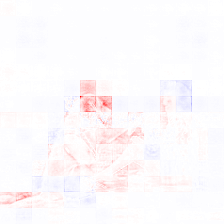

In [9]:
imgify(heatmap.detach().cpu().numpy(), vmin=-1, vmax=1)

## Qwen 3

In [1]:
import torch
from transformers import AutoTokenizer
from transformers.models.qwen3 import modeling_qwen3
from transformers import BitsAndBytesConfig

from lxt.efficient import monkey_patch
from lxt.utils import pdf_heatmap, clean_tokens

# modify the Qwen3 module to compute LRP in the backward pass
monkey_patch(modeling_qwen3, verbose=True)

# optional 4bit quantization 
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

path = 'Qwen/Qwen3-1.7B'
model = modeling_qwen3.Qwen3ForCausalLM.from_pretrained(path,
                                                        device_map='auto',
                                                        dtype=torch.bfloat16,
                                                        quantization_config=quantization_config)


tokenizer = AutoTokenizer.from_pretrained(path)

prompt = """Context: Mount Everest attracts many climbers, including highly experienced mountaineers. There are two main climbing routes, one approaching the summit from the southeast in Nepal (known as the standard route) and the other from the north in Tibet. While not posing substantial technical climbing challenges on the standard route, Everest presents dangers such as altitude sickness, weather, and wind, as well as hazards from avalanches and the Khumbu Icefall. As of November 2022, 310 people have died on Everest. Over 200 bodies remain on the mountain and have not been removed due to the dangerous conditions. The first recorded efforts to reach Everest's summit were made by British mountaineers. As Nepal did not allow foreigners to enter the country at the time, the British made several attempts on the north ridge route from the Tibetan side. After the first reconnaissance expedition by the British in 1921 reached 7,000 m (22,970 ft) on the North Col, the 1922 expedition pushed the north ridge route up to 8,320 m (27,300 ft), marking the first time a human had climbed above 8,000 m (26,247 ft). The 1924 expedition resulted in one of the greatest mysteries on Everest to this day: George Mallory and Andrew Irvine made a final summit attempt on 8 June but never returned, sparking debate as to whether they were the first to reach the top. Tenzing Norgay and Edmund Hillary made the first documented ascent of Everest in 1953, using the southeast ridge route. Norgay had reached 8,595 m (28,199 ft) the previous year as a member of the 1952 Swiss expedition. The Chinese mountaineering team of Wang Fuzhou, Gonpo, and Qu Yinhua made the first reported ascent of the peak from the north ridge on 25 May 1960. \
Question: How high did they climb in 1922? According to the text, the 1922 expedition reached 8,"""

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
input_ids = inputs.input_ids


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched Qwen3MLP
Patched Qwen3RMSNorm
Patched Dropout
Patched transformers.models.qwen3.modeling_qwen3


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


In [2]:

attention_mask = inputs.attention_mask

with torch.no_grad():
    generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask)
# tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


In [3]:
generated_ids.shape

torch.Size([1, 476])

In [ ]:

gen_ids = generated_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

tokenizer.batch_decode(gen_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'320 m (27,300 ft). The answer is...?\nA)'

In [6]:
L_gen = gen_ids.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [9]:
L_gen = gen_ids.size(1)
L_gen

20

In [12]:
# # optional gradient checkpointing to save memory (2x forward pass)
# model.train()
# model.gradient_checkpointing_enable()

# deactive gradients on parameters to save memory
for param in model.parameters():
    param.requires_grad = False


# get input embeddings so that we can compute gradients w.r.t. input embeddings
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).input_ids.to(model.device)
# input_embeds = model.get_input_embeddings()(input_ids)
input_embeds = model.get_input_embeddings()(generated_ids)

# inference and get the maximum logit at the last position (we can also explain other tokens)
output_logits = model(inputs_embeds=input_embeds.requires_grad_(), use_cache=False).logits


In [13]:
output_logits.shape

torch.Size([1, 476, 151936])

In [14]:
selected_logits = output_logits[0, indices, gen_ids[0]]   # [L_gen]

selected_logits.backward(torch.ones_like(selected_logits))
# equivalently: selected_logits.sum().backward()


In [35]:
# max_logits, max_indices = torch.max(output_logits[0, -1, :], dim=-1)

# # Backward pass (the relevance is initialized with the value of max_logits)
# # This initiates the LRP computation through the network
# max_logits.backward()

# obtain relevance by computing Input * Gradient
relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0] # cast to float32 before summation for higher precision

# normalize relevance between [-1, 1] for plotting
#relevance = relevance / relevance.abs().max()

In [16]:
# remove special characters from token strings and plot the heatmap
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens = clean_tokens(tokens)

# pdf_heatmap(tokens, relevance, path='qwen3_1.7B_heatmap.pdf', backend='xelatex') # backend='xelatex' supports more characters

# # plot again without first token, because it receives large relevance values overshadowing the rest
# pdf_heatmap(tokens[1:], relevance[1:] / relevance[1:].max(), path='qwen3_1.7B_heatmap_wo_first.pdf', backend='xelatex')

In [36]:
prompt_relevance = relevance[:ctx_len]
prompt_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0, :ctx_len])
prompt_tokens = clean_tokens(prompt_tokens)



In [37]:
import numpy as np
import matplotlib

def _apply_colormap(relevance, cmap_name="bwr"):
    """
    Map a scalar relevance in [-1, 1] to an RGB triplet in [0, 1].
    """
    # normalize from [-1, 1] to [0, 1]
    v = (relevance + 1.0) / 2.0
    v = np.clip(v, 0.0, 1.0)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    r, g, b, _ = cmap(v)
    return r, g, b


def _escape_html(text: str) -> str:
    return (
        text.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
    )

def _generate_html(words, relevances, cmap="bwr"):
    """
    Generate HTML code for a sentence with colored words based on their relevances.
    """
    html = []
    html.append("<!DOCTYPE html>")
    html.append("<html>")
    html.append("<head>")
    html.append('<meta charset="utf-8">')
    html.append("<style>")
    html.append("""
    body {
        font-family: sans-serif;
        max-width: 900px;
        line-height: 1.6;
        padding: 1rem;
    }
    .token {
        padding: 2px 3px;
        margin: 1px 1px;
        display: inline-block;
        font-family: monospace;
        border-radius: 2px;
    }
    """)
    html.append("</style>")
    html.append("</head>")
    html.append("<body>")

    for word, relevance in zip(words, relevances):
        r, g, b = _apply_colormap(float(relevance), cmap)
        R, G, B = int(r * 255), int(g * 255), int(b * 255)

        word_html = _escape_html(word)
        html.append(
            f'<span class="token" '
            f'style="background-color: rgb({R},{G},{B});">'
            f'{word_html}</span>'
        )

    html.append("</body>")
    html.append("</html>")

    return "\n".join(html)


In [38]:
def html_heatmap(words, relevances, path="heatmap.html", cmap="bwr"):
    """
    Write an HTML file with colored tokens according to relevance.
    No LaTeX, no external dependencies beyond matplotlib (for colormap).
    """
    html_code = _generate_html(words, relevances, cmap=cmap)

    with open(path, "w", encoding="utf-8") as f:
        f.write(html_code)

    print(f"Saved HTML heatmap to: {path}")
    return path


In [39]:
from IPython.display import HTML, display


# html_heatmap(prompt_tokens, prompt_relevance,
#             path='qwen3_1.7B_prediction_heatmap.html')
html_code = _generate_html(prompt_tokens, prompt_relevance, cmap="bwr")
display(HTML(html_code))

In [1]:
from huggingface_hub import login
login()

## Qwen VL


### Load model

In [2]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        # device_map="cuda:0",                  # split across GPU/CPU automatically
        device_map="auto",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


In [3]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [4]:
torch.cuda.device_count()

4

In [5]:
model.device

device(type='cuda', index=1)

In [6]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [8]:
from PIL import Image


def get_inputs(image: Image.Image, question: str):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
                },
            ],
        }
    ]
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

    inputs = inputs.to(model.device)
    return inputs

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> dict:
    

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)

    inputs = get_inputs(image, question)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()

    # first generate token id
    pred_token = int(answer_ids[0, 0].item())

    # answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "pred_token": pred_token,
        "answer_ids": answer_ids[0].cpu().tolist(), # all generated token ids 
    }

def get_target_token(golds, processor):
    """
    golds: list of string answers (already lower/strip if you want)
    returns: (token_ids, text_used)
    """
    # pick a canonical gold answer; here: the first one
    gold = golds[0]

    # tokenize WITHOUT adding special tokens
    enc = processor.tokenizer(
        gold,
        add_special_tokens=False,
        return_tensors=None,
    )
    token_ids = enc["input_ids"]  # this is a list[int]

    return token_ids[0]


In [9]:
import gc
verbose = False
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_token = pred_dict["pred_token"]
    pred_answer_ids = pred_dict["answer_ids"]
    # pred_tokens = pred_dict["tokens"]

    target_token = get_target_token(golds, processor)



    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "pred_token": pred_token,
            "target_token": target_token,
            "answer_ids": pred_answer_ids
            # "tokens": pred_tokens,
        }
    )
    gc.collect()
    torch.cuda.empty_cache()


In [10]:
torch.cuda.empty_cache()

In [11]:
records

[{'id': 0,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many food item is shown in the bar graph?',
  'gold_answers': ['14'],
  'prediction': '14',
  'correct': True,
  'pred_token': 16,
  'target_token': 16,
  'answer_ids': [16, 19, 151645]},
 {'id': 1,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'What is the difference in value between Lamb and Corn?',
  'gold_answers': ['0.57'],
  'prediction': '0.4',
  'correct': False,
  'pred_token': 15,
  'target_token': 15,
  'answer_ids': [15, 13, 19, 151645]},
 {'id': 2,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many bars are shown in the chart?',
  'gold_answers': ['3'],
  'prediction': '3',
  'correct': True,
  'pred_token': 18,
  'target_token': 18,
  'answer_ids': [18, 151645]},
 {'id': 3,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'Is the sum value 

In [12]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class QwenVL_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()
    
    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        image_grid_thw = inputs.get("image_grid_thw", None)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")


    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                image_grid_thw,
                return_probs=False,):

        # Vision embeddings
        image_embeds = self.hf_model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        
        image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        # if target_token is not None:
        #     target_token = 
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        if return_probs:
            # Compute the log_softmax
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32,
                return_logits=False):
        with torch.no_grad():
            outputs = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           output_hidden_states=return_logits,
                                           max_new_tokens=max_new_tokens)
        generated_ids = outputs.sequences

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # first generate token id
        pred_token = int(answer_ids[0, 0].item())
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        if return_logits:
            logits = [self.hf_model.lm_head(feats[-1]) for feats in outputs.hidden_states]
            return pred_token, answer_text, logits
        return pred_token, answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "QwenVL_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


#### Torchinfo

In [ ]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    1,505,280
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             1,280
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             4,919,040
│    │    │    └─Linear: 4-2                       [14308, 1280]             1,639,680
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             1,280
│    │  

In [ ]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           311,164,928
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           2,048
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           4,196,352
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           4,194,304
│    │    └─Qwen2RMSNorm: 3-3                 [1, 3609, 204

In [ ]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

In [ ]:
pred = records[0]["prediction"]

In [ ]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

### iGOS

In [13]:
"""
Utility functions for interpretation generation.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import os
import cv2
import sys

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from textwrap import fill
from io import BytesIO

# mean and standard deviation for the imagenet dataset
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

special_ids = [12, 13, 29871, 29889, 29892, 1919, 869, 29899, 29897, 29898, 278, 322, 310, 263, 385, 445, 393, 338, 411]
CHOICES = ['A','B','C','D','E','F']

def eprint(*args, **kwargs):
    """
        Prints to the std.err

    :param args:
    :param kwargs:
    :return:
    """
    print(*args, file=sys.stderr, **kwargs)


def get_data(args, row):
    if args.dataset == 'MMVP':
        photo_id = row['lndex']
        image_path = os.path.join(args.image_folder, f"{photo_id}.jpg")
        image = Image.open(image_path).convert('RGB')

        if args.choices:
            opts = row['Options'].split(' ')
            cur_prompt = f"{row['Question']}\nA. {opts[1]}\nB. {opts[3]}\n"
            qs = cur_prompt + "Answer only with the option's letter A or B from the given choices directly."
        else:
            qs = row['Question']
            cur_prompt = qs
    elif args.dataset == 'cvbench':
        image_path = os.path.join(args.image_folder, row["filename"])
        image = Image.open(image_path).convert('RGB')
        if args.choices:
            choices = row['choices']
            choices_text = ''
            for j,item in enumerate(choices):
                choices_text += f'\n{CHOICES[j]}. {item}'

            cur_prompt = row['question'] + choices_text
            qs = cur_prompt + '\nAnswer with the option\'s letter from the given choices directly.'
        else:
            qs = row['question']
            cur_prompt = qs
    elif args.dataset == 'mmstar':
        image_stream = BytesIO(row["image"]['bytes'])
        image = Image.open(image_stream).convert('RGB')
        if args.choices:
            cur_prompt = row['question']
            qs = cur_prompt + '\n' + "Answer with the option's letter from the given choices directly."
        else:
            qs = row['question'].split('?')[0] + '?'
            cur_prompt = qs
            
    elif args.dataset == 'llava-bench':
        image_path = os.path.join(args.image_folder, row["image"])
        image = Image.open(image_path).convert('RGB')
        cur_prompt = row['text']
        qs = cur_prompt
    return image, qs, cur_prompt
    

def get_kernel_size(image_size):
    if image_size[0] >=2000:
        kernel_size = 501
    elif image_size[0] >= 800:
        kernel_size = 301
    elif image_size[0] >= 500:
        kernel_size = 201
    else:
        kernel_size = 101
    return kernel_size

def save_heatmaps(masks, images, size, index, index_o, outdir, model_name, box, classes, labels, out=224):
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    masks = masks.view(-1, 1, size, size)
    up = torch.nn.UpsamplingBilinear2d(size=images.shape[-2:]).cuda()

    u_mask = up(masks)
    u_mask = u_mask.permute((0,2, 3, 1))

    # Normalize the mask
    u_mask = (u_mask - torch.min(u_mask)) / (torch.max(u_mask) - torch.min(u_mask))
    u_mask = u_mask.cpu().detach().numpy()

    # deprocess images
    images = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    images = images.numpy()

    for i, (image, u_mask) in enumerate(zip(images, u_mask)):

        # get the color map and normalize to 0-1
        heatmap = cv2.applyColorMap(np.uint8(255 * u_mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap / 255)
        # overlay the mask over the image
        #overlay = (u_mask ** 0.8) *0.5* image + (1 - u_mask ** 0.8) * heatmap
        overlay = 0.5 * heatmap + 0.5 * image
        cv2.normalize(overlay.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
        overlay[overlay < 0] = 0

        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_heatmap.jpg'), heatmap)
        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_overlay.jpg'), overlay)


def save_masks(masks, index, categories, mask_name, outdir):
    """
        Saves the generated masks as numpy.ndarrays.

    :param masks:
    :param index:
    :param categories:
    :param mask_name:
    :param outdir:
    :return:
    """
    masks = masks.cpu().detach().numpy()
    for i, (mask, category) in enumerate(zip(masks, categories), start=index):
        np.save(os.path.join(outdir, f'{mask_name}_{i+1}_mask_{category}.npy'), mask)

def save_loss(loss_del, loss_ins, loss_l1, loss_tv, loss_l2, index, index_o, outdir, loss_comb_del=None, loss_comb_ins=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    iterations = np.arange(len(loss_del))

    if loss_comb_del:
        ax1.plot(iterations, loss_comb_del, label='loss comb del', marker='^')
    if loss_comb_ins:
        ax1.plot(iterations, loss_comb_ins, label='loss comb ins', marker='<')
    ax1.plot(iterations, loss_del, label='loss del', marker='o')
    ax1.plot(iterations, loss_ins, label='loss ins', marker='s')

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss Value')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(iterations, loss_tv, label='loss TV', marker='o')
    ax2.plot(iterations, loss_l2, label='loss L2', marker='+')
    ax2.plot(iterations, loss_l1, label='loss L1', marker='x')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss Value')
    ax2.grid(True)
    ax2.legend()

    plt.savefig(os.path.join(outdir, f'{index}_{index_o}_losses.jpg'), bbox_inches='tight', pad_inches = 0)
    plt.close()

def save_curves(del_curve, ins_curve, index_curve, index, index_o, outdir):
    """
        Save the deletion/insertion curves for the generated masks.

    :param del_curve:
    :param ins_curve:
    :param index_curve:
    :param index:
    :param index_o:
    :param outdir:
    :return:
    """
    for i in range(len(del_curve)):
        fig, (ax, ax1) = plt.subplots(2, 1)
        ax.plot(index_curve, del_curve[i], color='r', label='deletion')
        ax.fill_between(index_curve, del_curve[i], facecolor='maroon', alpha=0.4)
        ax.set_ylim([-0.05, 1.05])
        ax.tick_params(labelsize=14)
        ax.set_yticks(np.arange(0, 1.01, 1))
        ax.legend(['Deletion'], fontsize='x-large')
        ax.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(del_curve[i])),  fontsize=14, horizontalalignment='center', verticalalignment='center')

        ax1.plot(index_curve, ins_curve[i], color='b', label='Insertion')
        ax1.fill_between(index_curve, ins_curve[i], facecolor='darkblue', alpha=0.4)
        ax1.set_ylim([-0.05, 1.05])
        ax1.tick_params(labelsize=14)
        ax1.set_yticks(np.arange(0, 1.01, 1))
        ax1.legend(['Insertion'], fontsize='x-large')
        ax1.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(ins_curve[i])), fontsize=14, horizontalalignment='center', verticalalignment='center')

        # save the plot
        plt.savefig(os.path.join(outdir, f'{index}_{index_o}_curves.jpg'), bbox_inches='tight', pad_inches = 0)
        plt.close()


def save_images(images, index, index_o, outdir, classes, labels, pred_data, text=None):
    """
        saves original images into output directory

    :param images:
    :param index:
    :param index_o:
    :param outdir:
    :param classes:
    :param labels:
    :return:
    """
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    images_ = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    for i, image in enumerate(images_):
        wrapped_text = fill(text, width=60)
        fig, ax = plt.subplots(figsize=(5, 5))

        plt.subplots_adjust(top=0.8)
        ax.imshow(image.numpy())
        ax.axis('off')
        fig.text(0.5, 0.9, wrapped_text, ha='center', va='top', wrap=True, fontsize=10)
        plt.savefig(os.path.join(outdir, f'{index+i}_{index_o}_image.jpg'), bbox_inches='tight', pad_inches=0.2)


def auc(array):
    """
        calculates area under the curve (AUC)

    :param array:
    :return:
    """
    return (sum(array) - array[0]/2 - array[-1]/2)/len(array)


def get_initial(pred_data, k, init_posi, init_val, input_size, out_size):
    """
        filter the detection results by the threshold (predicted score)

    :param pred_data:
    :param k:
    :param initial_posi:
    :param init_val:
    :param input_size:
    :param out_size:
    :return:
    """
    interval_r = (pred_data['boxes'][:,2] - pred_data['boxes'][:,0]) / k
    interval_c = (pred_data['boxes'][:,3] - pred_data['boxes'][:,1]) / k
    num_row = init_posi // k
    num_col = init_posi - num_row * k
    init_boxes = np.concatenate([
                            [pred_data['boxes'][:,0] + interval_r * num_row], # x1
                            [pred_data['boxes'][:,1] + interval_c * num_col], # y1
                            [pred_data['boxes'][:,0] + interval_r * (num_row + 1)], # x2
                            [pred_data['boxes'][:,1] + interval_c * (num_col + 1)], # y2
                            ], axis=0).T 

    pred_data['init_masks'] = []
    down = torch.nn.UpsamplingBilinear2d(size=(out_size, out_size))

    for ith, box in enumerate(init_boxes):
        init_mask = torch.zeros((input_size[0], input_size[1])).unsqueeze(0)
        init_mask[int(box[0]) : int(box[2]), int(box[1]) : int(box[3])] = 1

        if 'masks' in pred_data.keys():
            init_mask = init_mask * pred_data['masks'][ith]
        
        init_mask = down(init_mask.unsqueeze(0)) * init_val
        pred_data['init_masks'].append(1 - init_mask)
    return pred_data


def generate(args, model, input_ids, image, image_size):
    output_ids = model.generate(
            input_ids,
            images=image,
            #image_sizes=image_size,
            do_sample=True if args.temperature > 0 else False,
            temperature=args.temperature,
            top_p=args.top_p,
            num_beams=args.num_beams,
            max_new_tokens=args.max_new_tokens,
            use_cache=True)
    output_ids = output_ids[:,1:-1]
    return output_ids

def match_keywords(lst, sublist):
    lst_str = ','.join(map(str, lst))
    sublist_str = ','.join(map(str, sublist))
    start_idx = lst_str.find(sublist_str)

    if start_idx == -1:
        return None

    start = lst_str[:start_idx].count(',')
    end = start + len(sublist) - 1
    return [start, end]


In [14]:
"""
Helper function for the IGOS explanation methods.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import torch.nn.functional as F
import math

#from .utils import special_ids

def cosine_decay(init, iter):
    return init * (1 + math.cos(math.pi * iter)) / 2

def exp_decay(init, iter, gamma=0.2):
    return init * math.exp(-gamma * iter)

def tv_norm(image, beta=2):
    """
    Calculates the total variation.
    :param image:
    :param beta:
    :return:
    """
    image = image[:, 0, :, :]
    a = torch.mean(torch.abs((image[:, :-1, :] - image[:, 1:, :]).view(image.shape[0], -1)).pow(beta), dim=1)
    b = torch.mean(torch.abs((image[:, :, :-1] - image[:, :, 1:]).view(image.shape[0], -1)).pow(beta), dim=1)
    return a + b


def bilateral_tv_norm(image, mask, tv_beta=2, sigma=1):
    """
        Calculates the bilateral total variation.

    :param image:
    :param mask:
    :param tv_beta:
    :param sigma:
    :return:
    """
    # tv term
    mask_ = mask[:, 0, :]
    a = torch.mean(torch.abs((mask_[:, :-1, :] - mask_[:, 1:, :]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    b = torch.mean(torch.abs((mask_[:, :, :-1] - mask_[:, :, 1:]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    # bilateral tv in the image space
    if isinstance(image, list):
        image = image[0]
    elif image.shape[0] > 1:
        image = image[0].unsqueeze(0)

    up_mask_ = upscale(mask, image)
    bil_a = torch.mean(torch.exp(-(image[:, :, :-1, :] - image[:, :, 1:, :]).mean(dim=1) ** 2 / sigma).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :-1, :] - up_mask_[:, :, 1:, :]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)
    bil_b = torch.mean(torch.exp(-(image[:, :, :, :-1] - image[:, :, :, 1:]) ** 2 / sigma).mean(dim=1).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :, :-1] - up_mask_[:, :, :, 1:]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)
    return 0.5 * (a + b + bil_a + bil_b)



def upscale(masks: torch.Tensor, images, mode: str = 'bilinear', align_corners: bool = False):
    """
    将 masks 上采样到与 images 的空间尺寸一致。
    支持 images 为:
      - 单图 3D: [C, H, W]
      - 批量 4D: [B, C, H, W]
      - list[Tensor]: 每个为 [C,H,W] 或 [H,W]
    masks 形状可为 [h,w] / [B,h,w] / [B,1,h,w] / [1,1,h,w]
    """
    # 规范 masks -> [B,1,h,w]
    if masks.dim() == 2:
        masks = masks.unsqueeze(0).unsqueeze(0)           # [1,1,h,w]
    elif masks.dim() == 3:
        masks = masks.unsqueeze(1)                         # [B,1,h,w]
    elif masks.dim() == 4 and masks.size(1) != 1:         # [B,C,h,w] 但 C!=1
        masks = masks[:, :1, ...]                          # 取第1通道

    def _interp(msk, size_hw, dev):
        H, W = size_hw
        msk = msk.to(dev).float()
        return F.interpolate(msk, size=(H, W), mode=mode, align_corners=align_corners)

    # --- images 为单图 3D: [C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 3:
        _, H, W = images.shape
        # 若 masks 的 batch 是 1，就保持 1；也可按需 expand 到 1
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为批量 4D: [B,C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 4:
        B, _, H, W = images.shape
        if masks.size(0) == 1 and B > 1:
            masks = masks.expand(B, -1, -1, -1).contiguous()
        elif masks.size(0) != B:
            raise ValueError(f"Batch mismatch: masks B={masks.size(0)}, images B={B}")
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为 list
    if isinstance(images, list):
        outs = []
        for img in images:
            if img.dim() == 2:     # [H,W]
                H, W = img.shape[-2], img.shape[-1]
                dev = img.device
            elif img.dim() == 3:   # [C,H,W]
                _, H, W = img.shape
                dev = img.device
            else:
                raise ValueError("Each image in list must be 2D or 3D tensor.")
            outs.append(_interp(masks, (H, W), dev))       # -> [B,1,H,W]
        return outs

    raise ValueError("images must be a 3D/4D Tensor or a list of images.")

def interval_score(args, model, model_name, images, baseline, label, up_masks, num_iter, noise=True, 
                   prompt=None, image_size=None, positions=None):
    if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).cuda().view(-1, 1, 1, 1)
        interval_masks = up_masks.unsqueeze(1) * intervals
        local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

        if noise:
            local_images = local_images + torch.randn_like(local_images) * .2

        local_images = local_images.transpose(0, 1)
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(input_ids.device)

        losses = torch.tensor(0.).to(input_ids.device)
        for single_img in local_images:
            single_img = single_img.half()
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()
    
    elif model_name == 'cambrian':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).cuda().view(-1, 1, 1, 1)
        interval_masks = [up_mask.unsqueeze(1) * intervals for up_mask in up_masks]
        local_images = [phi(image.unsqueeze(1), base.unsqueeze(1), interval_mask) for image, base, interval_mask in zip(images, baseline, interval_masks)]

        if noise:
            local_images = [local_image + torch.randn_like(local_image) * .2 for local_image in local_images]

        local_images = [local_image.squeeze(0) for local_image in local_images]
        local_images = [[local_images[i][j] for i in range(len(local_images))] for j in range(num_iter)]
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(input_ids.device)
        losses = torch.tensor(0.).to(input_ids.device)

        for single_img in local_images:
            single_img = [item.unsqueeze(0).half() for item in single_img]
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()

    return losses / num_iter


def integrated_gradient(args, model, model_name, image, baseline, label, up_masks, num_iter,
                        noise=True, prompt=None, image_size=None, positions=None):
    loss = interval_score(
                args,
                model,
                model_name, 
                image,
                baseline,
                label,
                up_masks,
                num_iter,
                noise,
                prompt,
                image_size,
                positions
                )
    loss.sum().backward(retain_graph=True)
    return loss.sum().item()

def line_search(masks, total_grads, loss_func, alpha=8, beta=0.0001, decay=0.2,):
    # Speed up computations, reduce memory usage, and ensure no autograd
    # graphs are created
    with torch.no_grad():
        i = 0
        mod = len(masks.shape) - 3
        num_inputs = masks.shape[0]
        # The indices of masks that still need their alphas updated
        indices = torch.ones(num_inputs, dtype=torch.bool).cuda()
        # Create initial alpha values for each mask
        alphas = torch.ones(num_inputs).cuda() * alpha

        up_masks = upscale(masks.view(-1,*masks.shape[mod:])).view(-1, *masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)

        # Compute the base loss used in the condition
        base_losses = loss_func(up_masks, masks, indices).view(-1)
        t = -beta * (total_grads ** 2).view(num_inputs, -1).sum(dim=1).view(num_inputs)

        while True:
            # Create a new mask with the updated alpha value to
            # see if it meets condition
            new_masks = torch.clamp(masks[indices] - alphas[indices].view(-1,*(1,) * mod,1,1) * total_grads[indices], 0, 1)
            up_masks = upscale(new_masks.view(-1,*masks.shape[mod:])).view(-1,*masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)
            # Calculate new losses
            losses = loss_func(up_masks, new_masks, indices).view(-1)
            # Get indices for each alpha that meets the condition for
            # their corresponding mask
            indices[indices] = losses > base_losses[indices] + alphas[indices] * t[indices]
            # Same for this, but for if the alpha values are too low (\alpha_l)
            indices[indices] *= (alphas[indices] >= 0.00001)
            # Break out of the loop if all alpha values satisfy the condition
            # or are too low
            if not indices.sum():
                break
            # Otherwise update alphas
            alphas[indices] *= decay
            i += 1
    return alphas.view(-1,1,1,1)


def phi(img, baseline, mask):
    """
        Composes an image from img and baseline according to the mask values.

    :param img:
    :param baseline:
    :param mask:
    :return:
    """
    return img.mul(mask) + baseline.mul(1-mask)


def metric(args, image, baseline, mask, model, model_name, label, label_i, pred_data, size=28, prompt=None, image_size=None, positions=None, resolution=None):
    with torch.no_grad():
        # The dimensions for the image
        #img_size = image.shape[-1]
        # Compute the total number of pixels in a mask
        mask_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        num_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        # Compute the step size
        step=max(1, num_pixels // 50)
        # Used for indexing with batch sizes
        l = torch.arange(1)
        # The unmasked score
        og_scores = score_output(args, image, image_size, model, model_name, l, label, prompt, positions)
        # The baseline score
        blur_scores = score_output(args, baseline, image_size, model, model_name, l, label, prompt, positions)
        # Initial values for the curves
        del_curve = [og_scores]
        ins_curve = [blur_scores]
        index = [0.]

        # True_mask is used to hold 1 or 0. Either show that pixel or blur it.
        true_mask = torch.ones((mask.shape[0], mask_pixels)).cuda()
        del_scores = torch.zeros(mask.shape[0])
        ins_scores = torch.zeros(mask.shape[0])
        # Sort each mask by values and store the indices.
        elements = torch.argsort(mask.view(mask.shape[0], -1), dim=1)
        for pixels in range(0, num_pixels, step):
            # Get the indices used in this iteration
            indices = elements[l,pixels:pixels+step].squeeze().view(1, -1)
            # Set those indices to 0
            true_mask[l, indices.permute(1,0)] = 0
            up_mask = upscale(true_mask.view(-1, 1, size,size), image, resolution)
            # Mask the image for deletion
            if isinstance(image, list):
                del_image = [phi(x, y, z).half() for x, y, z in zip(image, baseline, up_mask)]
            else:
                del_image = phi(image, baseline, up_mask).half()
            # Calculate new scores
            outputs = score_output(args, del_image, image_size, model, model_name, l, label, prompt, positions)
            del_curve.append(outputs)
            index.append((pixels+step)/num_pixels)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            del_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

            # Mask the image for insertion
            if isinstance(image, list):
                ins_image = [phi(x, y, z).half() for x, y, z in zip(baseline, image, up_mask)]
            else:
                ins_image = phi(baseline, image, up_mask).half()

            # Calculate the new scores
            outputs = score_output(args, ins_image, image_size, model, model_name, l, label, prompt, positions)

            ins_curve.append(outputs)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            ins_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

        # Force scores between 0 and 1.
        del_scores /= num_pixels
        ins_scores /= num_pixels

        del_curve = list(map(lambda x: [y.item() for y in x], zip(*del_curve)))
        ins_curve = list(map(lambda x: [y.item() for y in x], zip(*ins_curve)))

    return del_scores, ins_scores, del_curve, ins_curve, index


def score_output(args, image, image_size, model, model_name, l, label, prompt, positions):
    input_ids = torch.cat((prompt, label), dim=1)
    probs_pred = pred_probs(args, model, input_ids, label, image, image_size).unsqueeze(0)
    scores = probs_pred[:, torch.tensor(positions).to(probs_pred.device)].sum(-1) 
    return scores / len(positions)

def pred_probs(model, inputs, generated_ids, image, target_token_position, selected_token_word_id, need_grad=False):
    inputs_new = inputs.copy()
    
    inputs_new['input_ids'] = generated_ids
    inputs_new['attention_mask'] = torch.ones_like(generated_ids)
    
    inputs_new['pixel_values'] = image
    inputs_new = inputs_new.to(model.device)
    
    # Forward calculation to get all logits (including the logits of the input part)
    if need_grad:
        outputs = model(
            **inputs_new,
            return_dict=True,
            use_cache=True,
        )
        all_logits = outputs.logits  # [batch_size, seq_len, vocab_size]
    else:
        with torch.no_grad():
            outputs = model(
                **inputs_new,
                return_dict=True,
                use_cache=True,
            )
            all_logits = outputs.logits  # [batch_size, seq_len, vocab_size]
    
    returned_logits = all_logits[:, target_token_position - 1] # The reason for the minus 1 is that the generated content is in the previous position
    returned_logits = F.softmax(returned_logits, dim=-1)
    
    selected_token_word_id = torch.tensor(selected_token_word_id).to(model.device)
    indices = selected_token_word_id.unsqueeze(0).unsqueeze(-1) # [1, N, 1]
    
    returned_logits = returned_logits.gather(dim=2, index=indices) # [1, N, 1]
    returned_logits = returned_logits.squeeze(-1)  # [1, N]
    
    return returned_logits[0]

def find_keywords(model,
                  inputs,
                  generated_ids,
                  output_ids, image,
                  blur_image,
                  target_token_position,
                  selected_token_word_id,
                  tokenizer=None):
    # select keywords according to logits drop
    # full_prompt = torch.cat((input_ids, output_ids), dim=1)
    probs = pred_probs(model, inputs, generated_ids, image, target_token_position, selected_token_word_id)
    probs_blur = pred_probs(model, inputs, generated_ids, blur_image, target_token_position, selected_token_word_id)

    probs = probs.cpu()
    probs_blur = probs_blur.cpu()

    # condition = (probs_blur <= 0.4*probs) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    condition = (torch.log(probs)-torch.log(probs_blur) > 1.0)& (probs>=0.0) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    positions = torch.where(condition)[0].tolist()
    
    if len(positions) == 0:
        idx = torch.argmax(probs-probs_blur).item()
        positions = [idx]
    
    keywords = [tokenizer.decode(output_ids[0][idx]).strip() for idx in positions]
    
    return positions, keywords




In [15]:
import time

import cv2
import numpy as np
import torch
from torch.autograd import Variable
from PIL import Image

# from .methods_helper import find_keywords, phi, pred_probs, bilateral_tv_norm, line_search, upscale, exp_decay
# from .utils import get_kernel_size, get_initial



# OpenAI CLIP 归一化常量
OPENAI_CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
OPENAI_CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

def pil_to_clip_tensor_bcwh(img, requires_grad=True, dtype=torch.float32, device=None):
    """
    将 PIL.Image 转为按 OpenAI CLIP 归一化的 tensor，维度为 [B, C, W, H]（B=1）。
    不进行 resize / crop；仅做 RGB 转换、[0,1] 归一化与标准化。
    
    Args:
        img: PIL.Image 或可被 PIL.Image.open 读取的路径
        requires_grad (bool): 返回的 tensor 是否需要梯度
        dtype: 返回 tensor 的数据类型（默认 float32）
        device: 返回 tensor 的设备（例如 "cuda" 或 torch.device(...)）

    Returns:
        x_bcwh: torch.Tensor, 形状 [1, 3, W, H]
    """
    # 1) 读图并确保 RGB
    if isinstance(img, (str, bytes, np.ndarray)):
        img = Image.open(img)
    img = img.convert("RGB")
    
    w, h = img.size
    new_w = round(w / 28) * 28
    new_h = round(h / 28) * 28
    
    img = img.resize((new_w, new_h), Image.BICUBIC)

    # 2) PIL -> numpy -> torch，归一到 [0,1]
    np_img = np.asarray(img, dtype=np.float32) / 255.0        # [H, W, 3]
    x = torch.from_numpy(np_img)                              # [H, W, 3]
    x = x.to(dtype=dtype)

    # 3) HWC -> CHW
    x = x.permute(2, 0, 1)                                    # [3, H, W]

    # 4) 按 CLIP 均值方差标准化
    mean = torch.tensor(OPENAI_CLIP_MEAN, dtype=dtype).view(3, 1, 1)
    std  = torch.tensor(OPENAI_CLIP_STD,  dtype=dtype).view(3, 1, 1)
    x = (x - mean) / std                                      # [3, H, W]

    # 5) 加 batch 维 -> [1, 3, H, W]
    x = x.unsqueeze(0)                                        # [1, 3, H, W]

    # 6) 设备与梯度设置
    if device is not None:
        x = x.to(device)
    x.requires_grad_(requires_grad)

    return x

def tensor2pack(patches: torch.Tensor) -> torch.Tensor:
    temporal_patch_size=2
    resized_height = patches.shape[2]
    resized_width = patches.shape[3]
    patch_size = 14
    merge_size = 2
    
    # 如果 B 不能整除 temporal_patch_size，就补齐
    if patches.shape[0] % temporal_patch_size != 0:
        repeats = patches[-1].unsqueeze(0).repeat(temporal_patch_size - 1, 1, 1, 1)
        patches = torch.cat([patches, repeats], dim=0)

    channel = patches.shape[1]
    grid_t = patches.shape[0] // temporal_patch_size
    grid_h, grid_w = resized_height // patch_size, resized_width // patch_size

    patches = patches.reshape(
        grid_t,
        temporal_patch_size,
        channel,
        grid_h // merge_size,
        merge_size,
        patch_size,
        grid_w // merge_size,
        merge_size,
        patch_size,
    )

    patches = patches.permute(0, 3, 6, 4, 7, 2, 1, 5, 8).contiguous()

    flatten_patches = patches.reshape(
        grid_t * grid_h * grid_w,
        channel * temporal_patch_size * patch_size * patch_size,
    )

    return flatten_patches

def gen_explanations_qwenvl(model, processor, image, text_prompt, tokenizer, positions=None, select_word_id=None):
    """_summary_

    Args:
        model (_type_): _description_
        processor (_type_): _description_
        image (_type_): PIL格式图片
        text_prompt (_type_): _description_
        device (_type_): _description_
    """
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    blur = cv2.GaussianBlur(np.asarray(image), (kernel_size, kernel_size), sigmaX=kernel_size-1)
    blur = Image.fromarray(blur.astype(np.uint8))
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": blur},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    text = processor.apply_chat_template(
            messages1, tokenize=False, add_generation_prompt=True)
    # image_tensor, _ = process_vision_info(messages1)
    # blur_tensor, _ = process_vision_info(messages2)
    
    inputs = processor(
            text=[text],
            images=[image],#image_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    inputs_blur = processor(
            text=[text],
            images=[blur],#blur_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    
    image_tensor = inputs['pixel_values']
    blur_tensor = inputs_blur['pixel_values']
    del inputs_blur
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :].cpu() for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    selected_token_word_id = generated_ids_trimmed[0].numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model,
                                            inputs,
                                            generated_ids,
                                            generated_ids_trimmed,
                                            image_tensor,
                                            blur_tensor,
                                            target_token_position,
                                            selected_token_word_id,
                                            tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[positions[0]]
    
    del image_tensor
    del blur_tensor
    torch.cuda.empty_cache()
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for _, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        # masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
        masks, _, _, _, _, _, _, _ = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=pil_to_clip_tensor_bcwh(image).to(model.device),
                target_token_position=target_token_position,
                selected_token_word_id=selected_token_word_id,
                baseline=pil_to_clip_tensor_bcwh(blur).to(model.device),
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=tensor2pack
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks)) 
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def gen_explanations_internvl(model, processor, image, text_prompt, tokenizer, positions=None, select_word_id=None):
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    
    # Preparation for inference
    inputs = processor.apply_chat_template(messages1,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt").to(model.device, dtype=torch.bfloat16)

    image_tensor = inputs['pixel_values']
    # blur_tensor = inputs_blur['pixel_values']
    blur_tensor = image_tensor * 0  # blur image cant choose salient word
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    selected_token_word_id = generated_ids_trimmed[0].cpu().numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model, inputs, generated_ids,
                                            generated_ids_trimmed, image_tensor,
                                            blur_tensor, target_token_position,
                                            selected_token_word_id, tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0], skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[positions[0]]
    
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    
    # new image
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image.resize((448, 448))},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    inputs = processor.apply_chat_template(messages2,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt"
                                           ).to(model.device, dtype=torch.bfloat16)
    input_ids = inputs["input_ids"]
    
    y = torch.stack(generated_ids_trimmed, dim=0)


    generated_ids = torch.cat([inputs["input_ids"], y if y.dim()==2 else y.unsqueeze(0)], dim=1).to(model.device)
    # inputs['attention_mask'] = torch.ones_like(inputs["input_ids"]).to(model.device)
    
    
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for l_i, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=inputs['pixel_values'][-1].unsqueeze(0).to(model.device),
                target_token_position=target_token_position, selected_token_word_id=selected_token_word_id,
                baseline=inputs['pixel_values'][-1].unsqueeze(0).to(model.device)*0,
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=None
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks))  
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def interval_score(model, inputs,
                   generated_ids,
                   images,
                   target_token_position,
                   selected_token_word_id,
                   baseline, up_masks,
                   num_iter, noise=True,
                   positions=None, processor=None):
    # if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
    # The intervals to approximate the integral over
    intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).cuda().view(-1, 1, 1, 1)
    interval_masks = up_masks.unsqueeze(1).to(model.device) * intervals.to(model.device)
    local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

    if noise:
        local_images = local_images + torch.randn_like(local_images) * .2

    local_images = local_images.transpose(0, 1)
    # input_ids = torch.cat((prompt, label), dim=1)
    positions = torch.tensor(positions).to(model.device)

    losses = torch.tensor(0.).to(model.device)
    for single_img in local_images:
        # single_img = single_img.half()
        
        if processor == None:
            single_input = single_img
        else:
            single_input = processor(single_img)
        
        probs = pred_probs(model, inputs,
                           generated_ids,
                           single_input,
                           target_token_position,
                           selected_token_word_id,
                           need_grad=True)
        #losses += probs[positions].mean()
        losses += torch.log(probs)[positions].sum()

    return losses / num_iter


def integrated_gradient(model,
                        inputs,
                        generated_ids, image,
                        target_token_position,
                        selected_token_word_id,
                        baseline, up_masks,
                        num_iter, noise=True,
                        positions=None,processor=None):
    loss = interval_score(
        model, 
        inputs, 
        generated_ids, 
        image, 
        target_token_position, 
        selected_token_word_id,
        baseline, 
        up_masks, 
        num_iter, 
        noise=noise, 
        positions=positions,
        processor=processor)
    
    loss.sum().backward(retain_graph=True)
    return loss.sum().item()

def iGOS_pp(
        model,
        inputs, 
        generated_ids,
        init_mask,
        image,
        target_token_position, 
        selected_token_word_id,
        baseline,
        label,
        size=32,
        iterations=15,
        ig_iter=20,
        L1=1,
        L2=1,
        L3=20,
        lr=1000,
        opt='LS',
        softmax=True,
        processor=None,
        **kwargs):

    L2 = 0.1
    gamma = 1.0
    momentum = 5
    
    def regularization_loss(image, masks):
        return L1 * torch.mean(torch.abs(1 - masks).view(masks.shape[0], -1), dim=1), \
               L3 * bilateral_tv_norm(image, masks, tv_beta=2, sigma=0.01), \
               L2 * torch.sum((1 - masks)**2, dim=[1, 2, 3])

    def ins_loss_function(up_masks, indices, noise=True):
        losses = -interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        
        return losses.sum(dim=1).view(-1)

    def del_loss_function(up_masks, indices, noise=True):
        losses = interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        return losses.sum(dim=1).view(-1)

    def loss_function(up_masks, masks, indices):
        loss = del_loss_function(up_masks[:, 0], indices)
        loss += ins_loss_function(up_masks[:, 1], indices)
        loss += del_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        loss += ins_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        return loss + regularization_loss(image[indices], masks[:, 0] * masks[:, 1])

    masks_del = torch.ones((1, 1, size, size), dtype=torch.float32, device='cuda')
    masks_del = masks_del * init_mask.cuda()
    masks_del = Variable(masks_del, requires_grad=True)
    masks_ins = torch.ones((image.shape[0], 1, size, size), dtype=torch.float32, device='cuda')
    masks_ins = masks_ins * init_mask.cuda()
    masks_ins = Variable(masks_ins, requires_grad=True)
    prompt = kwargs.get('prompt', None)
    image_size = kwargs.get('image_size', None)
    positions = kwargs.get('positions', None)
    resolution = kwargs.get('resolution', None)

    
    if opt == 'NAG':
        cita_d=torch.zeros(1).cuda()
        cita_i=torch.zeros(1).cuda()
    

    positions = kwargs.get('positions', None)
    losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins = [], [], [], [], [], [], []
    for i in range(iterations):
        up_masks1 = upscale(masks_del, image)
        up_masks2 = upscale(masks_ins, image)

        # Compute the integrated gradient for the combined mask, optimized for deletion
        loss_comb_del = integrated_gradient(model,
                                            inputs,
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor)
        
        total_grads1 = masks_del.grad.clone()
        total_grads2 = masks_ins.grad.clone()
        masks_del.grad.zero_()
        masks_ins.grad.zero_()

        # Compute the integrated gradient for the combined mask, optimized for insertion
        loss_comb_ins = integrated_gradient(model,
                                            inputs, 
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor)
        
        total_grads1 -= masks_del.grad.clone()  # Negative because insertion loss is 1 - score.
        total_grads2 -= masks_ins.grad.clone()
        masks_del.grad.zero_()
        masks_ins.grad.zero_()

        # Compute the integrated gradient for the deletion mask
        loss_del = integrated_gradient(model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks1,
                                       ig_iter,
                                       positions=positions, processor=processor)
        
        total_grads1 += masks_del.grad.clone()
        masks_del.grad.zero_()

        # Compute the integrated graident for the insertion mask
        loss_ins = integrated_gradient(model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks2,
                                       ig_iter,
                                       positions=positions, processor=processor)
        
        total_grads2 -= masks_ins.grad.clone()
        masks_ins.grad.zero_()

        # Average them to balance out the terms with the regularization terms
        total_grads1 /= 2
        total_grads2 /= 2

        # Computer regularization for combined masks
        L2 = exp_decay(L2, i, gamma)
        loss_l1, loss_tv, loss_l2 = regularization_loss(image, masks_del * masks_ins)
        losses = loss_l1 + loss_tv + loss_l2
        losses.sum().backward()
        total_grads1 += masks_del.grad.clone()
        total_grads2 += masks_ins.grad.clone()

        if opt == 'LS':
            masks = torch.cat((masks_del.unsqueeze(1), masks_ins.unsqueeze(1)), 1)
            total_grads = torch.cat((total_grads1.unsqueeze(1), total_grads2.unsqueeze(1)), 1)
            lrs = line_search(masks, total_grads, loss_function, lr)
            masks_del.data -= total_grads1 * lrs
            masks_ins.data -= total_grads2 * lrs
        
        if opt == 'NAG':
            e = i / (i + momentum)
            cita_d_p = cita_d
            cita_i_p = cita_i
            cita_d = masks_del.data - lr * total_grads1
            cita_i = masks_ins.data - lr * total_grads2
            masks_del.data = cita_d + e * (cita_d - cita_d_p)
            masks_ins.data = cita_i + e * (cita_i - cita_i_p)

        masks_del.grad.zero_()
        masks_ins.grad.zero_()
        masks_del.data.clamp_(0,1)
        masks_ins.data.clamp_(0,1)

        losses_del.append(loss_del)
        losses_ins.append(loss_ins)
        losses_comb_del.append(loss_comb_del)
        losses_comb_ins.append(loss_comb_ins)
        losses_l1.append(loss_l1.item())
        losses_tv.append(loss_tv.item())
        losses_l2.append(loss_l2.item())
        print(f'iteration: {i} lr: {lr:.4f} loss_comb_del: {loss_comb_del:.4f}, loss_comb_ins: {loss_comb_ins:.4f}, loss_del: {loss_del:.4f}, loss_ins: {loss_ins:.4f}, loss_l1: {loss_l1.item():.4f}, loss_tv: {loss_tv.item():.4f}, loss_l2: {loss_l2.item():.4f}')

    return masks_del * masks_ins, losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins



In [17]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'pred_token': 16,
 'target_token': 16,
 'answer_ids': [16, 19, 151645]}

In [18]:
# from src.explainers.igos_pp.igos import gen_explanations_qwenvl

image = records[0]["image"]
question = records[0]["question"]


In [19]:
heatmap, superimposed_img = gen_explanations_qwenvl(model, processor, image, question, tokenizer=processor.tokenizer)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


['1', '3', 'different', 'These', 'lamb', 'corn', 'barley', 'r', 'beef', 'wheat', 'coffee', 'tea', 'peanuts', 'palm', 'pork', 'rice', 'sugar', 'cocoa']


OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 1 has a total capacity of 44.52 GiB of which 14.50 MiB is free. Process 2143848 has 5.19 GiB memory in use. Including non-PyTorch memory, this process has 39.31 GiB memory in use. Of the allocated memory 35.26 GiB is allocated by PyTorch, and 3.55 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### TAM

In [16]:
from PIL import Image
import requests
from io import BytesIO


def get_input(processor,
              image=None,
              question=None,
              dtype=torch.bfloat16):
    if image is None:
        image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
        image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
    
    if question is None:
        question = "What is the color of the dog ?"

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    # "text": (
                    #     "Answer concisely with a single number, word or short phrase.\n"
                    #     f"Question: {question}"
                    # ),
                    "text": f"{question}",
                },
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image



In [17]:
image = records[0]["image"]
question = records[0]["question"]

image = None
# question = "What is the color of the dog ?"
question = "What animal is in the picture ?"

inputs, image = get_input(processor,
                          image=image,
                          question=question)

In [18]:
inputs = inputs.to(model.device)

In [19]:
from qwen_utils import process_vision_info

messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
                    #"text": f"{question}",
                },
            ],
        }
    ]
image_inputs, video_inputs = process_vision_info(messages)

In [20]:
outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        use_cache=True,
        output_hidden_states=True, # ---> TAM needs hidden states
        return_dict_in_generate=True
    )

generated_ids = outputs.sequences

In [21]:
outputs.hidden_states[0][0].shape

torch.Size([1, 3605, 2048])

In [22]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

In [23]:
prompt_len = inputs["input_ids"].shape[1]

In [24]:
output_text[0].strip()

'The animal in the picture is a dog.'

In [25]:
output_text

['The animal in the picture is a dog.']

In [26]:
generated_ids_trimmed

[tensor([   785,   9864,    304,    279,   6802,    374,    264,   5562,     13,
         151645], device='cuda:1')]

In [27]:
# Compute logits from last hidden states with vocab classifier for TAM
logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]

In [28]:
len(logits)

10

In [29]:
# Define special token IDs to separate image/prompt/answer tokens
# See TAM in tam.py about its usage. See ids from the specific model.
special_ids = {'img_id': [151652, 151653],
                'prompt_id': [151653, [151645, 198, 151644, 77091]], 
                'answer_id': [[198, 151644, 77091, 198], -1]}

In [30]:
vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)

# get img or video inputs for next vis
vis_inputs = image_inputs

In [25]:
import cv2
import numpy as np

from src.explainers.tam import id2idx, least_squares, multimodal_process

def get_attributions(tokens,
                    vision_shape,
                    logit_list,
                    special_ids, vision_input,
                    processor,
                    target_token_idx,
                    img_scores_list,
                    eval_only=True):


    # start and end id for img, prompt and answer
    img_id = special_ids['img_id']
    prompt_id = special_ids['prompt_id'] # prompt text, start and end id
    answer_id = special_ids['answer_id'] # number of tokens between prompt and answer
    
    # if img_id is a int, take all tokens same to this id
    if len(img_id) == 1:
        img_idx = (np.array(tokens) == img_id[0]).nonzero()[0]
    else:
        img_idx = [id2idx(tokens, img_id[0], True), id2idx(tokens, img_id[1])]

    # convert vocab id to idx in tokens
    prompt_idx = [id2idx(tokens, prompt_id[0], True), id2idx(tokens, prompt_id[1])]
    answer_idx = [id2idx(tokens, answer_id[0], True), id2idx(tokens, answer_id[1])]

    # decode ids
    prompt_tokens = tokens[prompt_idx[0] + 1: prompt_idx[1]]
    answer_tokens = tokens[answer_idx[0] + 1:]

    prompt = processor.tokenizer.tokenize(processor.batch_decode([prompt_tokens], \
            skip_special_tokens=False, clean_up_tokenization_spaces=False)[0])
    answer = processor.tokenizer.tokenize(processor.batch_decode([answer_tokens], \
            skip_special_tokens=False, clean_up_tokenization_spaces=False)[0])
    txt_all = prompt + answer


    # round_idx indicates the round of generation, this_token_idx is for the exaplained target token
    round_idx = -1
    this_token_idx = 0

    # for non-first rounds
    if isinstance(target_token_idx, int):
        round_idx = target_token_idx
        this_token_idx = -1 # last token of each answer round
        vis_token_idx = len(prompt) + target_token_idx

    # for the first round, which contrains multiple prompt tokens to explain
    else:
        round_idx, prompt_token_idx = target_token_idx
        this_token_idx = prompt_idx[0] + prompt_token_idx + 1
        vis_token_idx = prompt_token_idx


    
    # class activation map from logits of the target token class
    target_token = answer_tokens[target_token_idx]
    scores = torch.cat([logit_list[_][0, :, target_token] for _ in range(round_idx + 1)], -1).clip(min=0)

    # get relevance scores
    scores = scores.detach().cpu().float().numpy()
    prompt_scores = scores[prompt_idx[0] + 1: prompt_idx[1]]
    last_prompt = scores[logit_list[0].shape[1] - 1: logit_list[0].shape[1]]
    answer_scores = scores[answer_idx[0] + 1:]
    txt_scores = np.concatenate([prompt_scores, last_prompt, answer_scores], -1)

    txt_scores_raw = scores.copy()          # raw logit-based scores for all text positions
    prompt_scores_raw = prompt_scores.copy()
    answer_scores_raw = answer_scores.copy()


    if isinstance(img_idx, list):
        img_scores = scores[img_idx[0] + 1: img_idx[1]]
    else:
        img_scores = scores[img_idx]

    # save img_scores for next Estimated Causal Inference
    img_scores_list.append(img_scores)

    # exclude the same words in ECI
    if len(img_scores_list) > 1 and vis_token_idx < len(txt_all):
        non_repeat_idx = []
        for i in range(vis_token_idx):
            if i < len(txt_all) and txt_all[i] != txt_all[vis_token_idx]:
                non_repeat_idx.append(i)
        txt_scores_ = txt_scores[non_repeat_idx]
        img_scores_list_ = [img_scores_list[_] for _ in non_repeat_idx]

        # get the interference map of ECI
        w = txt_scores_
        w = w / (w.sum() + 1e-8)
        interf_img_scores = (np.stack(img_scores_list_, 0) * w.reshape(-1, 1)).sum(0)

        # apply ECI with the least squares method and relu
        scaled_map = least_squares(img_scores, interf_img_scores)
        img_scores = (img_scores - interf_img_scores * scaled_map).clip(min=0)

    # prepare raw vision input
    if isinstance(vision_shape[0], tuple):
        cv_img = [cv2.cvtColor(np.array(_), cv2.COLOR_RGB2BGR) for _ in vision_input]
    elif len(vision_shape) == 2:
        cv_img = np.array(vision_input)
        if len(cv_img.shape) == 4 and cv_img.shape[0] == 1:
            cv_img = cv_img[0]
        cv_img = cv2.cvtColor(cv_img, cv2.COLOR_RGB2BGR)
    else: #video
        cv_img = [cv2.cvtColor(np.array(_), cv2.COLOR_RGB2BGR) for _ in vision_input[0]]

    # prepare top candidates
    candi_scores, candi_ids = logit_list[round_idx][0, this_token_idx].topk(3)
    candi_scores = candi_scores.softmax(0)
    candidates = processor.batch_decode([[_] for _ in candi_ids])

    img_scores_raw = img_scores.copy()
    # apply the multimodal_process to obtain TAM
    vis_img, img_map_norm, txt_scores_norm = multimodal_process(cv_img, vision_shape,
                                                           img_scores, txt_scores,
                                                            txt_all, candidates,
                                                            candi_scores, vis_token_idx, \
                                                            img_save_fn="",
                                                            eval_only=eval_only,
                                                            vis_width=-1 if eval_only else 500)
    
    ### Block add to retrieve the both relevance
    return {
    "raw_img":          cv_img,
    "vis_img":          vis_img,           # None if eval_only and no save_fn
    "img_map_norm":     img_map_norm,      # post-RGF map, [0,255]
    "img_scores_raw":   img_scores_raw,    # pre-norm, post-ECI
    "txt_scores_raw":   txt_scores_raw,    # full raw scores for all text positions
    "txt_scores_norm":  txt_scores_norm,   # full normalized scores (prompt+answer)
    "prompt_tokens":    prompt_tokens,            # decoed prompt tokens
    "answer_tokens":    answer_tokens,            # decoded answer tokens
    "prompt_scores_raw": prompt_scores_raw,
    "answer_scores_raw": answer_scores_raw,
}




In [31]:
from captum.attr import visualization
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import cv2

from src.explainers.tam import get_attributions

def get_attributions_plot(model_wrapper,
                          inputs,
                          true_text,
                          target_token=None,
                          target_token_idx=0,
                          pred_token=None,
                          plot=False,
                          cmap=None):

    outputs = model_wrapper.hf_model.generate(
        **inputs,
        max_new_tokens=32,
        use_cache=True,
        output_hidden_states=True, # ---> TAM needs hidden states
        return_dict_in_generate=True
    )

    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = outputs.sequences
    answer_ids = generated_ids[:, prompt_len+target_token_idx]
    out = processor.batch_decode(
                    answer_ids,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=False
            )[0]
    print(answer_ids)
    pred_text = out.strip()

    # Compute logits from last hidden states with vocab classifier for TAM
    logits = [model_wrapper.hf_model.lm_head(feats[-1]) for feats in outputs.hidden_states]

    vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)

    # get img or video inputs for next vis
    vis_inputs = image_inputs


    # Make a forward and predictions
    if pred_token is None:
        pred_token = int(answer_ids[0, 0].item())
    
    if target_token is None:
        target_token = pred_token


    # Get attributions
    result = get_attributions(
                generated_ids[0].cpu().tolist(),        
                vision_shape,
                logits,
                special_ids,
                vis_inputs,
                model_wrapper.processor,
                target_token_idx=target_token_idx,
                img_scores_list=[],
                eval_only=True)
    
    
    img_attribution = result["img_map_norm"]
    text_attribution = result["prompt_scores_raw"]
    
    if plot:
        if cmap is None:
            cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )

        # Plot image attribution
        img_resized_np = result["raw_img"].astype(np.float32) / 255.0

        h, w, _ = img_resized_np.shape
        img_map = cv2.resize(img_attribution, (w, h))

        visualization.visualize_image_attr_multiple(
            #img_map,
            np.expand_dims(img_map, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "positive", "positive"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
            cmap=cmap,
        )

        # Plot text attribution
        text_attributions_norm = np.abs(text_attribution).max()
        text_attr = text_attribution / text_attributions_norm
        text_attr_vis = (2 * text_attr) -1

        prompt_tokens = result["prompt_tokens"]
        prompt_text = model_wrapper.processor.batch_decode(
                                    [prompt_tokens],
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]


        vis_data_records = [visualization.VisualizationDataRecord(
                                    text_attr_vis,
                                    target_token,
                                    pred_text,
                                    true_text,
                                    target_token,
                                    text_attr_vis.sum(),       
                                    prompt_text.split(),
                                    0.0)]
        visualization.visualize_text(vis_data_records)

     
    return img_attribution, text_attribution



In [41]:
import os
from src.explainers.tam import TAM

raw_map_records = []
save_dir = "/home/jky/xai-vdoc-benchmark/data/img/"

target_token_idx = 1

# for i in range(len(logits)):
# result = TAM(
#         generated_ids[0].cpu().tolist(),
#         vision_shape,
#         logits,
#         special_ids,
#         vis_inputs,
#         processor,
#         save_fn=os.path.join(save_dir, str(target_token_idx) + '.jpg'),
#         target_token=target_token_idx,
#         #target_token=(0, 1),
#         img_scores_list=raw_map_records,
#         eval_only=False)

result = get_attributions(
                generated_ids[0].cpu().tolist(),        
                vision_shape,
                logits,
                special_ids,
                vis_inputs,
                processor,
                target_token_idx,
                raw_map_records,
                eval_only=True)


In [33]:
model_wrapper = QwenVL_Wrapper(model, processor)
true_text = "yellow"
target_token = generated_ids_trimmed[0][0].item()
pred_token = target_token

# true_text = records[0]["gold_answers"]
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]

In [76]:
output_text

['The dog in the picture is yellowish-brown, also known as golden-yellow.']

In [31]:
generated_ids_trimmed

[tensor([   785,   9864,    304,    279,   6802,    374,    264,   5562,     13,
         151645], device='cuda:2')]

tensor([5562], device='cuda:2')


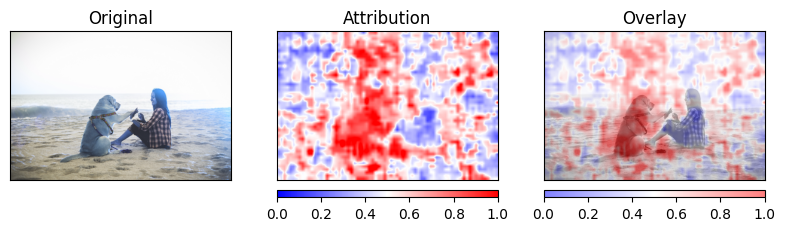

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,4.04,What animal is in the picture ?


In [36]:
true_text = "dog"
target_token_idx = 7
target_token = generated_ids_trimmed[0][target_token_idx].item()
pred_token = target_token
attributions = get_attributions_plot(model_wrapper,
                                    inputs,
                                    true_text,
                                    target_token_idx=target_token_idx,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    plot=True)

tensor([5562], device='cuda:0')


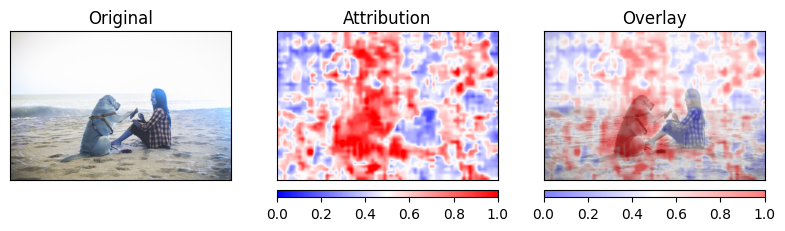

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
yellow,dog (6802.00),6802,4.21,{'What is the color of the dog ?'}


In [ ]:
target_token_idx = 8
target_token = generated_ids_trimmed[0][target_token_idx].item()
pred_token = target_token
attributions = get_attributions_plot(model_wrapper,
                                    inputs,
                                    true_text,
                                    target_token_idx=target_token_idx,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    plot=True)

In [37]:
torch.cuda.empty_cache()

### Captum

In [38]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [39]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization


def prepare_for_visualization(original_image, pixel_attr, image_grid_thw, cmap=None):
        
        grid_t, grid_h, grid_w = image_grid_thw.tolist()  # e.g. [1, H_patches, W_patches]

        pixel_attr = pixel_attr.view(grid_t, grid_h, grid_w, -1)[0]
        pixel_attr = pixel_attr.mean(axis=-1)

        # --- normalize to [-1, 1] ---
        pixel_attr = pixel_attr / pixel_attr.abs().max()

        heat_2d_np = pixel_attr.to(torch.float32).cpu().numpy()
        # --- 3. to uint8 and PIL image (grayscale) ---
        # heat_2d_np = (heat_2d_np * 255).astype("uint8")

        img_resized_np = np.asarray(original_image).astype(np.float32) / 255.0  # [H, W, 3]
        h, w, c = img_resized_np.shape
        heat_up = cv2.resize(heat_2d_np, (w, h))

        # -- Use Captum's visualize_image_attr_multiple ---
        if cmap is None:
            cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


        visualization.visualize_image_attr_multiple(
            np.expand_dims(heat_up, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "all", "all"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
            cmap=cmap
        )


In [40]:
from einops import rearrange

from src.explainers.tam import id2idx

# Define special token IDs to separate image/prompt/answer tokens
# See TAM in tam.py about its usage. See ids from the specific model.
special_ids = {'img_id': [151652, 151653],
                'prompt_id': [151653, [151645, 198, 151644, 77091]], 
                'answer_id': [[198, 151644, 77091, 198], -1]}

def get_attributions_plot(model_wrapper,
                          attr_hf,
                          inputs,
                          image,
                          true_text,
                          target_token=None,
                          pred_token=None,
                          pred_text=None,
                          use_baselines=False,
                          plot=False,
                          cmap=None):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw
    return_probs = True

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids, image_grid_thw, return_probs)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, pred_text = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)
        
    if target_token is None:
        target_token = pred_token


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=target_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=target_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    if plot:
        # Image visualization
        pixel_attr = attributions[1].cpu().detach()
        image_grid_thw = inputs.image_grid_thw
        prepare_for_visualization(image, pixel_attr,
                                    image_grid_thw[0],
                                    cmap=cmap)
        

        # Token visualization
        img_mask = (input_ids == model_wrapper.processor.image_token_id)
        token_mask = (input_ids != model_wrapper.processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_id = special_ids["prompt_id"]
        prompt_idx = [id2idx(input_ids[token_mask].tolist(), prompt_id[0], True),
                    id2idx(input_ids[token_mask].tolist(), prompt_id[1])]
        
        raw_text_attr = attributions[0][token_mask][prompt_idx[0]+1 :prompt_idx[1], :].detach().cpu()
        text_attributions_norm = raw_text_attr.sum(dim=1).norm()
        text_attr = raw_text_attr.sum(dim=1) / text_attributions_norm

        prompt_text = model_wrapper.processor.batch_decode(
                                    input_ids[token_mask][prompt_idx[0]+1 :prompt_idx[1]].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token,
                            pred_text,
                            true_text,
                            target_token,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)

    
    
    return attributions


In [30]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'pred_token': 16,
 'target_token': 16,
 'answer_ids': [16, 19, 151645]}

In [ ]:
model_wrapper = QwenVL_Wrapper(model, processor)
# img = records[0]['image']
# question = records[0]['question']
# inputs = get_inputs(img, question)
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]
# true_text = records[0]['gold_answers']
# pred_text = records[0]['prediction']

In [41]:
model_wrapper = QwenVL_Wrapper(model, processor)
img = image
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]
#true_text = records[0]['gold_answers']
pred_text = "dog"

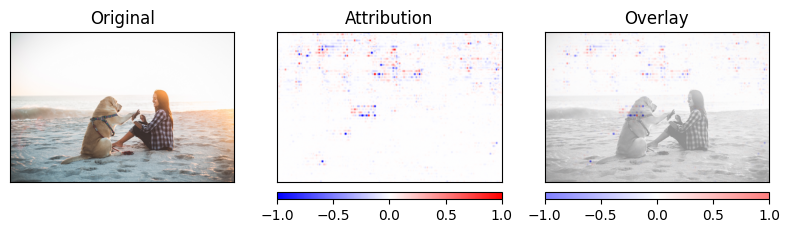

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,-0.33,What animal is in the picture ?


In [42]:
attr_hf = InputXGradient(model_wrapper)

attributions = get_attributions_plot(model_wrapper,
                                    attr_hf,
                                    inputs,
                                    image=img,
                                    true_text=true_text,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    pred_text=pred_text,
                                    use_baselines=False,
                                    plot=True,
                                    cmap=None
                                     )

#### Faithfulness metrics

In [160]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict, Optional, Callable


@torch.no_grad()
def eval_image_perturbation_batch(
    model_wrapper,
    # inpts,
    pixel_values: Tensor,
    target_idx: Tensor,           # (B,) tensor of class indices
    pixel_attribution: Tensor,    # (B, H, W) or (B, 1, H, W) or (B, C, H, W)
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor], Tensor],
    mask_value: float = 0.0,
    descending: bool = True,      # True: most important first; False: least important
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax
) -> Dict[str, np.ndarray]:
    """
    Batch-level image perturbation evaluation.

    Args
    ----
    model_wrapper: nn.Module
        Wrapper with:
            - .text_embeddings_layer(input_ids)
            - __call__(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids) -> logits
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, C, H, W),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices.
    pixel_attribution: Tensor
        (B, H, W) or (B, 1, H, W) or (B, C, H, W): saliency over image.
    perturbation_steps: list/tuple of float
        Fractions of pixels to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_value: float
        Value to put in perturbed pixels.
    descending: bool
        If True, remove most-attributed pixels first (deletion curve).
        If False, remove least-attributed pixels first (negative curve).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    pixel_values = pixel_values.to(device)
    pixel_attribution = pixel_attribution.to(device)
    target_idx = target_idx.to(device).long()

    # ---------- normalize shapes & define feature/position dims ----------
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape

    if ndim == 4: # (B, C, H, W)
        B, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.view(B, C, num_pixels) # (B, C, H*W)
    elif ndim == 3: # (B, num_patches, patch_dim)
        B, num_pixels, patch_dim = origin_shape
        feat = pixel_values.transpose(1, 2) # (B, patch_dim, num_patches)
    else:
        raise ValueError("The pixel values do not have the good dim")

    if pixel_attribution.ndim == 3: # (B, H, W)
        sal_flat = pixel_attribution.view(B, -1) # (B, num_pixels)
    elif pixel_attribution.ndim == 2: # (B, num_patches)
        sal_flat = pixel_attribution
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B,num_patches).")
    
    # print(f"feat size {feat.shape} - {pixel_values.shape}")
    # print(f"sal size{sal_flat.shape} - {pixel_attribution.shape}")

    # ---- baseline forward ----
    baseline_logits = forward_fn(pixel_values)        # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()           # (B, C)
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)           # (B, C)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)   # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B,2),(B,2)

    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )                                                   # (B,)
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx)  # (B,)

    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    num_feats = feat.shape[1] # C or patch_dim

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        k = int(round(step * num_pixels))
        k = max(1, min(k, num_pixels))

        # top-k spatial indices per image
        _, flat_idx = torch.topk(
            sal_flat,
            k,
            dim=-1,
            largest=descending,
        )  # (B, k)


        # clone pixel values and mask selected pixels across channels
        feat_pert = feat.clone()
        # expand indices to channels
        flat_idx_expanded = flat_idx.unsqueeze(1).expand(B, num_feats, k) # (B, num_feats, k)
        # build src tensor filled with mask_value
        mask_src = torch.full_like(feat_pert[:, :, :k], mask_value)
        # scatter over flattened spatial dimension
        feat_pert.scatter_(
            dim=2,
            index=flat_idx_expanded,
            src=mask_src,
        ) # (B, num_feats, k)

        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            perturbed_pixels = feat_pert.view(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            perturbed_pixels = feat_pert.transpose(1, 2)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")

        # forward with perturbed pixels
        logits_pert = forward_fn(perturbed_pixels)  # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                                             # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)                                             # (B, C)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)      # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)             # (B, 2)

        # probability delta (top-1 prob)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]  # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # logit delta (top-1 logit)
        logit_delta = pert_max_logit - baseline_max_logit              # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # dissimilarity after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()

        # accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx)                     # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }

@torch.no_grad()
def eval_token_perturbation_batch(
    model_wrapper,
    # inpts,
    input_ids: Tensor,
    attention_mask: Tensor,
    target_idx: Tensor,          # (B,) tensor of class indices
    token_attribution: Tensor,   # (B, L) token-wise attribution scores
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor, Tensor], Tensor],
    mask_token_id: int,
    pad_token_id: int,
    descending: bool = True,
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax,
    text_token_mask: Optional[Tensor] = None, # Bool of size (B, L) or None
) -> Dict[str, np.ndarray]:
    """
    Batch-level token perturbation evaluation for a VLM wrapper.

    Args
    ----
    model_wrapper: nn.Module
        Your wrapper with a forward like:
            model_wrapper(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids)
        and a `.text_embeddings_layer(input_ids)` method.
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, ...),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices for each sample.
    token_attribution: Tensor
        (B, L) attribution scores per token.
    perturbation_steps: list/tuple of float
        Fractions of tokens to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_token_id: int
        Token id that will replace perturbed tokens.
    pad_token_id: int
        Padding token id. If mask_token_id == pad_token_id,
        the attention mask is updated accordingly.
    descending: bool
        If True, mask most important tokens first (positive perturbation).
        If False, mask least important tokens first (negative perturbation).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    target_idx = target_idx.to(device)                  # (B,)
    token_attribution = token_attribution.to(device)

    B, L = input_ids.shape

    # ---- baseline forward ----
    baseline_logits = forward_fn(input_ids, attention_mask)       # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()          # (B, C)  # multi-label-ish
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)  # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B, 2), (B, 2)

    # per-sample dissimilarity: log(p_top1 / p_top2)
    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )  # (B,)

    # correctness: is top-1 predicted equal to target?
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx).float()  # (B,)

    # store as numpy
    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.float().cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    # ---- text mask ----
    if text_token_mask is not None:
        text_token_mask = text_token_mask.to(device).bool()  # (B, L)
    else:
        # by default: all positions are perturbable
        text_token_mask = torch.ones(B, L, dtype=torch.bool, device=device)

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        # make a *per-sample* selection mask (B, L)
        select_mask = torch.zeros(B, L, dtype=torch.bool, device=device)

        for b in range(B):
            # attribution and mask for that sample
            attr_b = token_attribution[b].clone()         # (L,)
            mask_b = text_token_mask[b]                   # (L,)

            # only consider text tokens
            valid_idx = mask_b.nonzero(as_tuple=False).view(-1)   # (M,)
            if valid_idx.numel() == 0:
                continue  # nothing to perturb in this sample

            # how many text tokens to perturb for this step?
            M = valid_idx.numel()
            k_b = int(round(step * M))
            k_b = max(1, min(k_b, M))

            # restrict attribution to valid positions
            attr_valid = attr_b[valid_idx]               # (M,)
            topk_rel = torch.topk(attr_valid, k_b, largest=descending)
            topk_idx_valid = topk_rel.indices           # (k_b,)
            topk_idx = valid_idx[topk_idx_valid]        # (k_b,) indices in [0, L)

            select_mask[b, topk_idx] = True
    

        # create perturbed input ids: (B, L)
        perturbed_ids = input_ids.clone()
        perturbed_ids[select_mask] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            # perturbed_mask[batch_idx, indices] = 0
            perturbed_mask[select_mask] = 0


        # ---- perturbed forward ----
        logits_pert = forward_fn(perturbed_ids, perturbed_mask)    # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)     # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)            # (B, 2)

        # Probability delta (top-1 prob change)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]   # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # Logit delta (top-1 logit change)
        logit_delta = pert_max_logit - baseline_max_logit                # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # Confidence margin after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        

        # Accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx).float()                      # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }


In [21]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [22]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = attributions[1].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [23]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [25]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.48192138671874996,
 'negative_auc': -0.41773681640625,
 'gap_auc': 0.0641845703125}

In [27]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [28]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [30]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.938403320312499,
 'negative_auc': -9.849566650390624,
 'gap_auc': -4.911163330078124}

#### Image visualization

In [ ]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization

def normalize_similarity_map(similarity_map: torch.Tensor,
                             value_range=None,
                             eps: float = 1e-8) -> torch.Tensor:
    """
    Min-max normalize a similarity / attribution map to [0, 1].

    similarity_map: torch.Tensor of arbitrary shape (e.g. [H, W])
    value_range: (min, max) or None. If None, use min/max from the tensor.
    """
    if value_range is None:
        vmin = similarity_map.min()
        vmax = similarity_map.max()
    else:
        vmin, vmax = value_range

    denom = (vmax - vmin).clamp(min=eps)
    return (similarity_map - vmin) / denom

def prepare_for_visualization(original_image, pixel_attr, image_grid_thw,
                              patch_size=14):
        grid_t, grid_h, grid_w = image_grid_thw.tolist()  # e.g. [1, H_patches, W_patches]

        pixel_attr = pixel_attr.view(grid_t, grid_h, grid_w, -1)[0]
        pixel_attr = pixel_attr.mean(axis=-1)
        pixel_attr = pixel_attr / pixel_attr.abs().max()

        # pixel_attr = (pixel_attr - pixel_attr.min()) / (pixel_attr.max() - pixel_attr.min() + 1e-8)

        # resized_height = grid_h * patch_size
        # resized_width  = grid_w * patch_size

        #  # resize original image to match the grid resolution
        # img_resized = original_image.resize((resized_width, resized_height), Image.BILINEAR)
        # img_resized_np = np.asarray(img_resized).astype(np.float32) / 255.0  # [H, W, 3]

         # --- 2. normalize to [0, 1] ---
        # heat_2d = normalize_similarity_map(pixel_attr, value_range=None)
        heat_2d_np = pixel_attr.to(torch.float32).cpu().numpy()       # [H_p, W_p]
        # print(pixel_attr)
        # --- 3. to uint8 and PIL image (grayscale) ---
        heat_2d_uint8 = (heat_2d_np * 255).astype("uint8")
        # print(heat_2d_uint8)
        # heat_pil = Image.fromarray(heat_2d_uint8, mode="L")

        # # --- 4. resize heatmap to original image size using PIL (your approach) ---
        # heat_pil_resized = heat_pil.resize(original_image.size, Image.Resampling.BICUBIC)

        # heat_up = np.asarray(heat_pil_resized).astype(np.float32) / 255.0  # [H, W]

        img_resized_np = np.asarray(original_image).astype(np.float32) / 255.0  # [H, W, 3]
        h, w, c = img_resized_np.shape
        heat_up = cv2.resize(heat_2d_uint8, (w, h))

        # --- 5. Use Captum's visualize_image_attr_multiple ---
        visualization.visualize_image_attr_multiple(
            np.expand_dims(heat_up, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "all", "all"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
        )


In [76]:
pixel_attr.shape

torch.Size([2520, 1176])

tensor([[ 0.0068,  0.0012,  0.0053,  ...,  0.0031,  0.0016,  0.0020],
        [ 0.0012,  0.0005, -0.0006,  ..., -0.0171,  0.0074, -0.0173],
        [-0.0045, -0.0003,  0.0044,  ...,  0.0006, -0.0001, -0.0003],
        ...,
        [-0.0029,  0.0080, -0.0017,  ..., -0.0628, -0.0355, -0.0187],
        [-0.0026,  0.0027,  0.0028,  ..., -0.0060,  0.0071,  0.0294],
        [ 0.0346, -0.0999, -0.0354,  ..., -0.0051, -0.0578,  0.0232]])
[[  1   0   1 ...   0   0   0]
 [  0   0   0 ... 252   1 252]
 [255   0   1 ...   0   0   0]
 ...
 [  0   2   0 ... 240 247 252]
 [  0   0   0 ... 255   1   7]
 [  8 231 247 ... 255 242   5]]


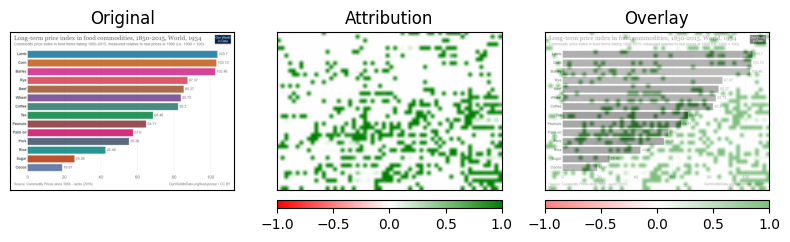

In [77]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = attributions[1].cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

In [35]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [36]:
import matplotlib.pyplot as plt


def show_side_by_side(original_image, pixel_values, pixel_attr, image_grid_thw,
                      patch_size=14, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    heat_2d = pv_attr.mean(axis=-1)
    heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1)
    pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    resized_H = grid_h * patch_size
    resized_W = grid_w * patch_size

    # resize original image to match
    img_resized = original_image.resize((resized_W, resized_H))
    

    _, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_resized)
    axs[0].set_title("Original (resized)")
    axs[0].axis("off")

    axs[1].imshow(pv, cmap=cmap)
    axs[1].set_title("pixel_values (mean per patch)")
    axs[1].axis("off")

    axs[2].imshow(heat_2d, cmap=cmap)
    axs[2].set_title("pixel_values attributions (mean per patch)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()


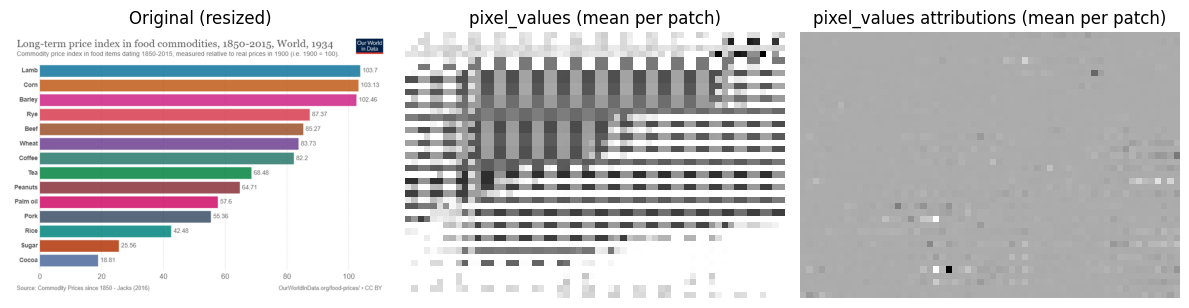

In [37]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

In [38]:
import matplotlib.pyplot as plt
from captum.attr import visualization


def show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    # heat_2d = pv_attr.mean(axis=-1)
    # heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1).unsqueeze(2)
    # pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    # resized_H = grid_h * patch_size
    # resized_W = grid_w * patch_size
    print(pv.shape, pv_attr.shape)


# --- 5. Use Captum's visualize_image_attr_multiple ---
    visualization.visualize_image_attr_multiple(
        pv_attr.cpu().detach().numpy(),
        pv.cpu().detach().numpy(),
        methods=["original_image", "heat_map", "blended_heat_map"],
        signs=["all", "all", "all"],
        show_colorbar=True,
        titles=["Original", "Attribution", "Overlay"],
    )


torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


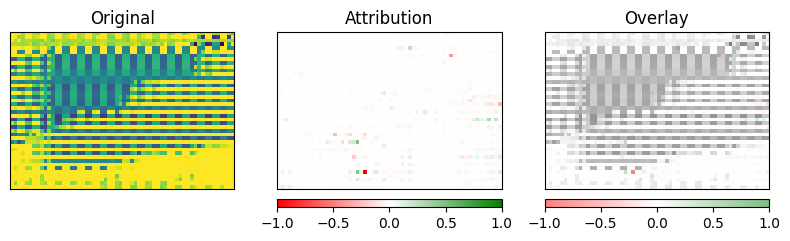

In [39]:
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap="gray")

#### Token visualization

In [40]:
attributions[0].shape

torch.Size([1, 678, 2048])

In [41]:
img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()


In [42]:
attributions[0][token_mask].shape

torch.Size([48, 2048])

In [43]:
# text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
# text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm

text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

In [44]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

In [ ]:
target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]
pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [49]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|vision_end|>Answer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph?<|im_end|>\n<|im_start|>assistant\n'

In [50]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

### LXT

In [43]:
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit


def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp



In [44]:
use_zennit = False
attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }

monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl


In [45]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()
model_wrapper = QwenVL_Wrapper(model, processor)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [36]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)
target_token = records[0]["target_token"]
pred_token = records[0]["pred_token"]
true_text = records[0]['gold_answers']
pred_text = records[0]['prediction']

In [46]:
zennit_comp = configure_lxt(model_wrapper.hf_model, use_zennit=False)

In [47]:
torch.cuda.empty_cache()


#### Attribution

In [48]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization

from src.explainers.tam import id2idx
from viz_utils import prepare_for_visualization


def get_relevance(model_wrapper,
                  inputs,  
                  image,
                    true_text,
                    target_token=None,
                    pred_token=None,
                    pred_text=None,
                    zennit_comp=None,
                    plot=False,
                    cmap=None):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    # if gen_ids is not None:
    #     ctx_len = input_ids.size(1)
    #     gen_ids_new = gen_ids[:, ctx_len:]
    #     L_gen = gen_ids_new.size(1)
    #     input_ids = torch.cat([input_ids, gen_ids_new], dim=1)
    #     attention_mask = torch.ones_like(input_ids, device=model.device)

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()
    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids, image_grid_thw,
                            return_probs=True)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()

    # if not full_relevance:
    #     inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # # inference and get the maximum logit at the last position (we can also explain other tokens)
    # outputs = model(
    #                 #input_ids=input_ids,
    #                 inputs_embeds=inputs_embeds,
    #                 attention_mask=attention_mask,
    #                 #image_grid_thw=image_grid_thw,
    #                 #pixel_values=pixel_values,
    #                 #position_ids=position_ids,
    #                 use_cache=False
    #                 )
    
    # output_logits = outputs["logits"]

    # if gen_ids is not None:
    #     L_gen = gen_ids_new.size(1)
        
    #     # positions whose logits predict each generated token
    #     indices = torch.arange(
    #         ctx_len - 1,
    #         ctx_len - 1 + L_gen,
    #         device=model.device
    #     )  # shape [L_gen]

    #     selected_logits = output_logits[0, indices, gen_ids_new[0]]   # [L_gen]
    #     selected_logits.backward(torch.ones_like(selected_logits))
    # else:
    #     max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
    #     max_logits.backward()

    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()

    if plot:
        # Image visualization
        pixel_attr = relevance_img.clone()
        image_grid_thw = inputs.image_grid_thw
        prepare_for_visualization(image, pixel_attr,
                                    image_grid_thw[0],
                                    cmap=cmap)
        

        # Token visualization
        img_mask = (input_ids == model_wrapper.processor.image_token_id)
        token_mask = (input_ids != model_wrapper.processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_id = special_ids["prompt_id"]
        prompt_idx = [id2idx(input_ids[token_mask].tolist(), prompt_id[0], True),
                    id2idx(input_ids[token_mask].tolist(), prompt_id[1])]
        
        print(relevance_text.shape)
        raw_text_attr = relevance_text[token_mask][prompt_idx[0]+1 :prompt_idx[1]].detach().cpu()
        # text_attributions_norm = raw_text_attr.sum(dim=-1).norm()
        text_attr = raw_text_attr / raw_text_attr.abs().max()

        prompt_text = model_wrapper.processor.batch_decode(
                                    input_ids[token_mask][prompt_idx[0]+1 :prompt_idx[1]].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token,
                            pred_text,
                            true_text,
                            target_token,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)
    
    return relevance_img, relevance_text


       

In [40]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)
target_token = records[0]["target_token"]
pred_token = records[0]["pred_token"]
true_text = records[0]['gold_answers']
pred_text = records[0]['prediction']

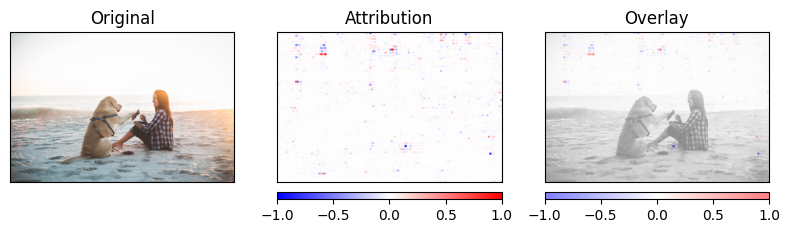

torch.Size([1, 3605])


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,2.12,What animal is in the picture ?


In [49]:
relevance_img, relevance_text = get_relevance(model_wrapper,
                                                inputs,
                                                image=img,
                                                true_text=true_text,
                                                target_token=target_token,
                                                pred_token=pred_token,
                                                pred_text=pred_text,
                                                plot=True,
                                                cmap=None
                                    )

In [52]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [56]:
relevance_text[token_mask][5:23]

tensor([ 1.0863e-03, -6.2467e-03, -1.2574e-03,  1.3438e-03, -5.0137e-03,
         3.9785e-03, -1.1392e-03,  3.2119e-04,  4.1774e-03, -3.0998e-03,
         9.5781e-04, -8.6544e-04, -1.1016e-03, -1.0989e-03,  1.2531e-04,
         8.2651e-05, -3.2567e-04,  3.6205e-03])

In [74]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [77]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

In [78]:
torch.cuda.empty_cache()

In [83]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

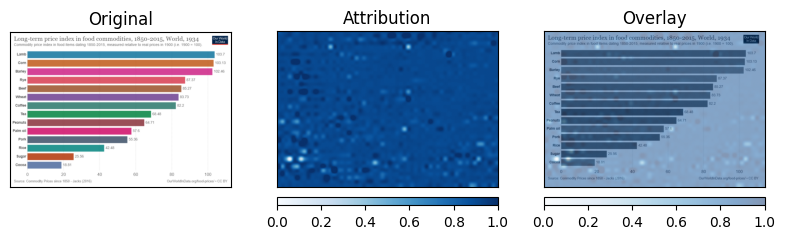

In [86]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = relevance_img.cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

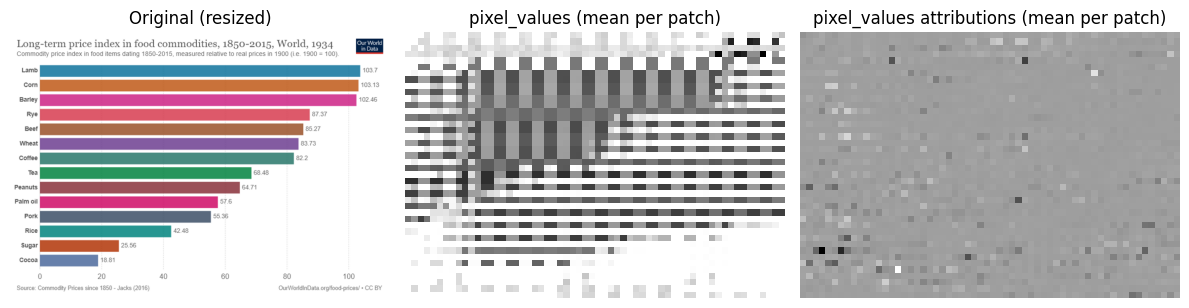

In [88]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


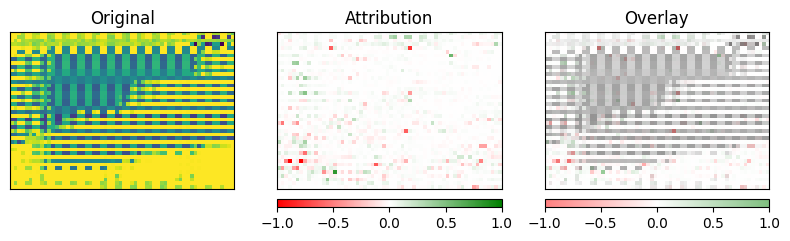

In [90]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap=default_cmap)

#### Faithfulness

In [93]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [94]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = relevance_img.cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [95]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [97]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.63931884765625,
 'negative_auc': -0.25439453124999994,
 'gap_auc': 0.38492431640624997}

In [98]:
relevance_text.shape

torch.Size([1, 678])

In [99]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [100]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [102]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -7.162341308593749,
 'negative_auc': -8.68472900390625,
 'gap_auc': -1.5223876953125}

#### Draft code

In [79]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()

pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

EinopsError:  Error while processing rearrange-reduction pattern "c h w -> h w c".
 Input tensor shape: torch.Size([1176]). Additional info: {}.
 Wrong shape: expected 3 dims. Received 1-dim tensor.

In [ ]:
# image_grid_thw: (B, 3) tensor from the processor

image_grid_thw = inputs["image_grid_thw"]

img_idx = 0
grid_t, grid_h, grid_w = image_grid_thw[img_idx].tolist()  # e.g. [1, H_patches, W_patches]

# relevance: (N,) = (grid_t * grid_h * grid_w,)
relevance_patches = relevance_img.view(grid_t, grid_h, grid_w)

relevance_map = relevance_patches[0]      # (grid_h, grid_w)
patch_size = processor.image_processor.patch_size

resized_height = grid_h * patch_size
resized_width  = grid_w * patch_size

import torch.nn.functional as F

# (H_patches, W_patches) -> (1,1,H_patches,W_patches)
relevance_map_2d = relevance_map.unsqueeze(0).unsqueeze(0)

# Upsample to resized image size
heatmap_resized = F.interpolate(
    relevance_map_2d,
    size=(resized_height, resized_width),
    mode="bilinear",
    align_corners=False,
)  # shape: (1,1,resized_height,resized_width)

heatmap_resized = heatmap_resized.squeeze(0).squeeze(0)  # (resized_height, resized_width)



In [56]:
torch.cuda.empty_cache()

In [ ]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def reshape_visual_relevance(model, processor, image_size):

    patch_size = processor.image_processor.patch_size
    spatial_merge_size = model.config.vision_config.spatial_merge_size

    height_new, width_new = smart_resize(
        width=image_size[0],
        height=image_size[1],
        factor=patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.size["shortest_edge"],
        max_pixels=processor.image_processor.size["longest_edge"],
    )


    n_patches_x = width_new // patch_size // spatial_merge_size
    n_patches_y = height_new // patch_size // spatial_merge_size
    return (n_patches_x, n_patches_y)


def visualize_image_relevance(image, img_relevance, figsize=(8,8), save_path=None):


    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
            image.size, Image.Resampling.BICUBIC
    )
    # similarity_map_image = Image.fromarray(img_relevance.cpu().numpy()).resize(
    #         image.size, Image.Resampling.BICUBIC
    # )
    
    show_colorbar = False
    # Create the figure
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            similarity_map_image,
            cmap=sns.color_palette("bwr", as_cmap=True),
            alpha=0.5,
        )

        if show_colorbar:
            fig.colorbar(im)
        ax.set_axis_off()
        fig.tight_layout()

        # ---- SAVE FIGURE ----
        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_image_relevance_(image, img_relevance, figsize=(8, 8), save_path=None):
    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    # img_relevance: torch.Tensor of shape (H_patches, W_patches), values in [-1, 1]
    rel = img_relevance.cpu().numpy().astype("float32")  # (Hp, Wp)
    similarity_map_image = Image.fromarray(rel, mode="F").resize(
        image.size, Image.Resampling.BICUBIC
    )
    print(similarity_map_image.size)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            np.array(similarity_map_image),
            cmap="bwr",
            alpha=0.5,
            vmin=-1,
            vmax=1,
        )

        ax.set_axis_off()
        fig.tight_layout()

        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_text_relevance(text, token_relevance, figsize=(8,8), save_path=None):

    # "Importance": abs by default (signed scores → magnitude)
    idx_max = int(torch.argmax(token_relevance))

    # Keep it readable: show top-k (optional)
    k = min(30, len(text))
    top_idx = torch.topk(token_relevance, k).indices.tolist()[::-1]  # highest → lowest
    top_text = [text[i] for i in top_idx]
    top_imp    = token_relevance[top_idx].numpy()

    # Colors: grey for all, one highlighted
    colors = ['lightgray'] * k
    colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

    plt.figure(figsize=figsize)
    y = np.arange(k)
    plt.barh(y, top_imp, color=colors)
    plt.yticks(y, top_text)
    plt.gca().invert_yaxis()
    plt.xlabel('Token importance (|relevance|)')
    plt.title('Top-k token attributions (max highlighted)')
    plt.tight_layout()
    # ---- SAVE FIGURE ----
    if save_path is None:
        save_path = "relevance_prompt_overlay.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")



In [58]:
relevance_text_norm = relevance_text / relevance_text.abs().max()
if full_relevance:
    relevance_img_norm = relevance_img / relevance_img.abs().max()
else:
    relevance_img_norm = None

In [42]:
inputs["input_ids"].shape

torch.Size([1, 3606])

In [43]:
relevance_text_norm.shape

torch.Size([3606])

In [64]:
from einops import rearrange

def prepare_relevance_for_visualization(input_ids, image, processor,
                                        image_grid_thw,
                                        relevance_text_norm,
                                        relevance_img_norm=None):
    img_mask = (input_ids == processor.image_token_id)
    token_mask = (input_ids != processor.image_token_id)
    img_mask = img_mask.cpu()
    token_mask = token_mask.cpu()

    idx = 0
    image_size = image.size
    n_patches = reshape_visual_relevance(model, processor, image_size)

    if relevance_img_norm is None:
        patch_relevance = rearrange(
                            relevance_text_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
                            "(h w) -> w h",
                            w=n_patches[0],
                            h=n_patches[1],
                        )  # (n_patches_x, n_patches_y, dim)
        
    else:
        assert(relevance_text_norm[img_mask[idx]].sum().cpu().numpy() == 0)


        # image_grid_thw: (B, 3) tensor from the processor
        grid_t, grid_h, grid_w = image_grid_thw[idx].tolist()  # e.g. [1, H_patches, W_patches]

        # relevance: (N,) = (grid_t * grid_h * grid_w,)
        patch_relevance = relevance_img_norm.view(grid_t, grid_h, grid_w)

    ids = input_ids[idx][token_mask[idx]]
    token_relevance = relevance_text_norm[token_mask[idx]]

    prompt_text = processor.batch_decode(
        ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
    )

    return token_relevance, patch_relevance, prompt_text


In [65]:
relevance_text_norm.shape

torch.Size([3606])

In [66]:
input_ids.shape

torch.Size([1, 3606])

In [67]:
input_ids = inputs["input_ids"]
image_grid_thw = inputs["image_grid_thw"]

use_target = False
if use_target:
    ctx_len = input_ids.size(1)
    gen_ids_new = gen_ids[:, ctx_len:]
    input_ids = torch.cat([input_ids, gen_ids_new], dim=1)

token_relevance, \
patch_relevance, \
prompt_text = prepare_relevance_for_visualization(input_ids,
                                                image,
                                                processor,
                                                image_grid_thw,
                                                relevance_text_norm,
                                                relevance_img_norm=relevance_img_norm)

In [75]:
full_relevance

True

In [76]:
patch_relevance.sum()

tensor(1.0861)

In [73]:
visualize_image_relevance(image, patch_relevance[0])


In [49]:
visualize_text_relevance(prompt_text, token_relevance)

In [17]:
image.size

(2048, 1365)

In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## Llava 1-5

In [1]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig

model_id = "llava-hf/llava-1.5-7b-hf"

def load_llava_model(model_id):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)
    
    model = LlavaForConditionalGeneration.from_pretrained(
        model_id, 
        dtype=torch.bfloat16, 
        low_cpu_mem_usage=True,
        quantization_config=bnb_config,
    ).to(0)

    processor = AutoProcessor.from_pretrained(model_id)
    return model, processor

In [2]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affi

In [4]:
model.vision_tower

CLIPVisionModel(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(577, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear4bit(in_features=1024, out_

In [5]:
model.language_model

LlamaModel(
  (embed_tokens): Embedding(32064, 4096)
  (layers): ModuleList(
    (0-31): 32 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((4096,), eps=1e-05)
  (rotary_emb): LlamaRotaryEmbedding()
)

In [5]:
torch.cuda.empty_cache()

In [4]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [6]:
from PIL import Image


def get_inputs(image: Image.Image, question: str):
    conversation = [
        {

        "role": "user",
        "content": [
            {"type": "text", "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
            },
            {"type": "image"},
            ],
        },
    ]
    # Preparation for inference
    prompt = processor.apply_chat_template(
        conversation, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=prompt,
        images=image,
        # padding=True,
        return_tensors="pt",
    )

    inputs.to(model.device)
    return inputs

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> dict:
    

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)

    inputs = get_inputs(image, question)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()
    # answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "first_tokens": answer_ids[:, 0].cpu(),
        # "tokens": answer_tokens
    }



In [7]:
import gc
verbose = True
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_first_tokens = pred_dict["first_tokens"]
    # pred_tokens = pred_dict["tokens"]

    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "first_tokens": pred_first_tokens,
            # "tokens": pred_tokens,
        }    
    )
    gc.collect()
    torch.cuda.empty_cache()


[0] Q: How many food item is shown in the bar graph?
    gold: ['14']
    pred: 10
    correct: False

[1] Q: What is the difference in value between Lamb and Corn?
    gold: ['0.57']
    pred: 100
    correct: False

[2] Q: How many bars are shown in the chart?
    gold: ['3']
    pred: 2
    correct: False

[3] Q: Is the sum value of Madagascar more then Fiji?
    gold: ['no']
    pred: No
    correct: True

[4] Q: What's the value of the lowest bar?
    gold: ['23']
    pred: 23
    correct: True

[5] Q: What is the difference between the highest and the lowest green bar??
    gold: ['6']
    pred: 20
    correct: False

[6] Q: What percent who think of President Donald Trump as Dangerous?
    gold: ['62']
    pred: 52
    correct: False

[7] Q: Is the sum of the percents of Charismatic and Well-qualified to be president more than A strong leader ?
    gold: ['yes']
    pred: Yes
    correct: True

[8] Q: What was the 4th most popular emotion?
    gold: ['inspired']
    pred: Anger


In [9]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class Llava_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                return_probs=False
                ):
        

        # Vision embeddings
        image_features = self.hf_model.model.get_image_features(
                pixel_values=pixel_values,
                vision_feature_layer=None,
                vision_feature_select_strategy=None,
                image_sizes=None,
            )
        image_features = torch.cat(image_features, dim=0).to(text_embeds.device, text_embeds.dtype)
        special_image_mask = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_features
        )
        inputs_embeds = text_embeds.masked_scatter(special_image_mask, image_features)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        # Compute the log_softmax
        if return_probs:
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
        # del outputs
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "Llava_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


### Captum

In [10]:
model_wrapper = Llava_Wrapper(model, processor)


In [11]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [12]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [13]:
from einops import rearrange

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

def get_attributions_plot(model_wrapper, attr_hf,
                          inputs, target_token,
                          true_class,
                          pred_token=None,
                          pred_class=None,
                          use_baselines=False,
                          plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, pred_class = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    if plot:
        # Token attribution
        img_mask = (input_ids == processor.image_token_id)
        token_mask = (input_ids != processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
        
        text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
        text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            true_class,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)


        # Pixel attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        visualization.visualize_image_attr_multiple(attributions_img,
                                                    original_im_mat, 
                                                    methods=["original_image", "heat_map", "blended_heat_map"],
                                                    signs=["all", "all", "all"],
                                                    titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                                    cmap=default_cmap,
                                                    show_colorbar=True)


    return attributions



In [14]:
attr_hf = InputXGradient(model_wrapper)
# attr_hf = IntegratedGradients(model_wrapper)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],-0.44,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


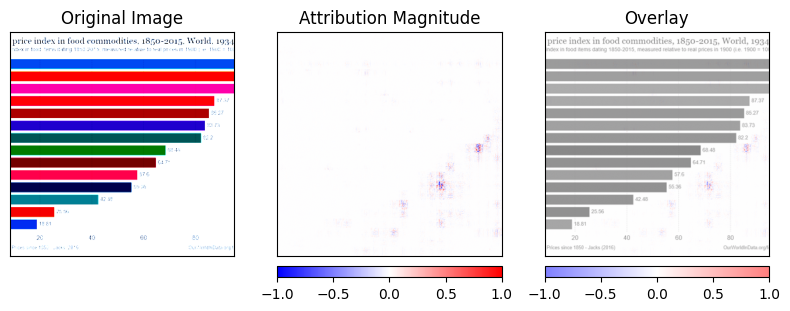

In [16]:
attributions = get_attributions_plot(model_wrapper,
                                     attr_hf=attr_hf,
                                     inputs=inputs,
                                     target_token=target_token,
                                     true_class=true_class,
                                     pred_token=target_token,
                                     pred_class=pred_class,
                                     use_baselines=False,
                                     plot=True
                                     )

In [17]:
torch.cuda.empty_cache()

#### Faithfulness

In [18]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [24]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(attributions[1], 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [26]:
pixel_attribution.shape

torch.Size([1, 336, 336])

In [27]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [28]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.033935546875,
 'negative_auc': -0.033062744140625,
 'gap_auc': 0.0008728027343749999}

In [29]:
attributions[0].shape

torch.Size([1, 616, 4096])

In [30]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [31]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [32]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -1.5392822265625004,
 'negative_auc': -4.85869140625,
 'gap_auc': -3.3194091796875}

#### Text attribution

In [ ]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [39]:
attributions[0][token_mask].shape

torch.Size([40, 4096])

In [44]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<s> USER:  \nAnswer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph? ASSISTANT:'

In [47]:
# Visualize text attributions
text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm


# Visualize text attributions
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


#### Image attribution

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


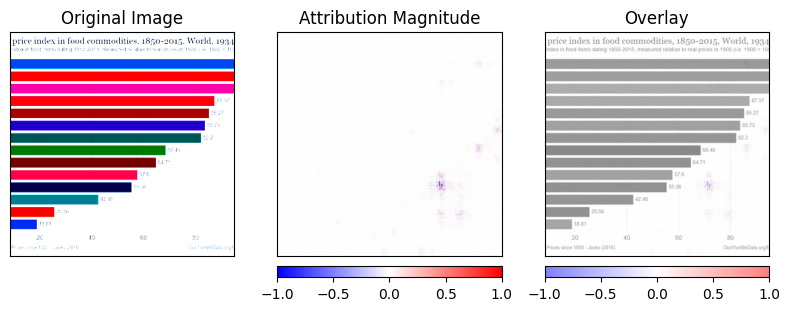

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [56]:
# visualize image attributions
original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            show_colorbar=True)

In [57]:
attributions_img.shape

(336, 336, 3)

In [22]:
type(model.vision_tower)

transformers.models.clip.modeling_clip.CLIPVisionModel

In [23]:
type(model.language_model)

transformers.models.llama.modeling_llama.LlamaModel

In [26]:
type(model)

transformers.models.llava.modeling_llava.LlavaForConditionalGeneration

### LXT

In [33]:
from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from transformers.models.llama import modeling_llama
from transformers.models.llama.modeling_llama import LlamaMLP, LlamaRMSNorm
from transformers.models.clip import modeling_clip
from transformers.models.llava import modeling_llava

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules



def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp


In [34]:
use_zennit = False
attnLRP = {
    LlamaMLP: partial(patch_method, gated_mlp_forward),
    LlamaRMSNorm: partial(patch_method, rms_norm_forward),
    Dropout: partial(patch_method, dropout_forward),
    modeling_llama: patch_attention,
    modeling_clip: patch_attention,
    modeling_clip.nn.LayerNorm: partial(patch_method, layer_norm_forward),
}

monkey_patch(modeling_llava, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched LlamaMLP
Patched LlamaRMSNorm
Patched Dropout
Patched transformers.models.llama.modeling_llama
Patched transformers.models.clip.modeling_clip
Patched LayerNorm


In [35]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()
model_wrapper = Llava_Wrapper(model, processor)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [36]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [37]:
zennit_comp = configure_lxt(model_wrapper.hf_model, use_zennit=False)

In [38]:
torch.cuda.empty_cache()


#### Attribution

In [39]:
def get_relevance(model_wrapper, inputs, zennit_comp=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()

    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    
    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()


    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()
    return relevance_img, relevance_text
    # else:
    #     relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
    #     return relevance, relevance

       

In [41]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )

In [43]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [46]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [47]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


In [48]:
torch.cuda.empty_cache()

In [ ]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

In [50]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()
pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


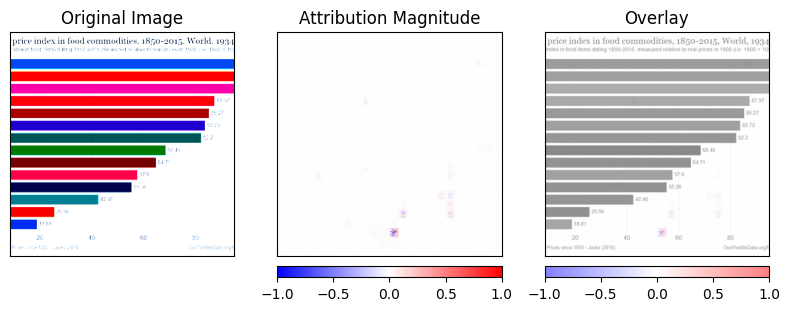

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [51]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

visualization.visualize_image_attr_multiple(attributions_img,
                                            original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            #outlier_perc=0,
                                            show_colorbar=True)

#### Faithfulness

In [54]:
relevance_img.shape

torch.Size([1, 3, 336, 336])

In [52]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [55]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(relevance_img, 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [56]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [57]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.039239501953125006,
 'negative_auc': -0.035369873046875,
 'gap_auc': 0.0038696289062500003}

In [58]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [59]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [60]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.2718750000000005,
 'negative_auc': -0.978533935546875,
 'gap_auc': 3.293341064453125}

## CLIPModel

In [ ]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32") 

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [23]:
from PIL import Image
import requests

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=False)


In [24]:
image.size

(640, 480)

In [26]:
list(inputs.keys())

['pixel_values', 'input_ids', 'attention_mask']

In [27]:
inputs.input_ids.shape

torch.Size([2, 7])

In [28]:
inputs.pixel_values.shape

torch.Size([1, 3, 224, 224])

In [29]:
outputs = model(**inputs)

In [31]:
outputs.logits_per_text.shape

torch.Size([2, 1])

In [32]:
outputs.logits_per_image.shape

torch.Size([1, 2])

In [ ]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class CLIP_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                return_probs=False
                ):
        

        # Vision embeddings
        image_features = self.hf_model.model.get_image_features(
                pixel_values=pixel_values,
                vision_feature_layer=None,
                vision_feature_select_strategy=None,
                image_sizes=None,
            )
        image_features = torch.cat(image_features, dim=0).to(text_embeds.device, text_embeds.dtype)
        special_image_mask = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_features
        )
        inputs_embeds = text_embeds.masked_scatter(special_image_mask, image_features)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        # Compute the log_softmax
        if return_probs:
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
        # del outputs
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "Llava_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


## GLM4v

In [2]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Glm4vForConditionalGeneration

model_id = "zai-org/GLM-4.1V-9B-Thinking"

def load_qwen_model(model_id):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id, use_fast=True)

    model = Glm4vForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor

In [3]:
model_id = "zai-org/GLM-4.1V-9B-Thinking"
model, processor = load_qwen_model(model_id)
model.eval()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Glm4vForConditionalGeneration(
  (model): Glm4vModel(
    (visual): Glm4vVisionModel(
      (embeddings): Glm4vVisionEmbeddings(
        (position_embedding): Embedding(576, 1536)
      )
      (patch_embed): Glm4vVisionPatchEmbed(
        (proj): Conv3d(3, 1536, kernel_size=(2, 14, 14), stride=(2, 14, 14))
      )
      (rotary_pos_emb): Glm4vVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Glm4vVisionBlock(
          (norm1): Glm4vRMSNorm((1536,), eps=1e-05)
          (norm2): Glm4vRMSNorm((1536,), eps=1e-05)
          (attn): Glm4vVisionAttention(
            (qkv): Linear4bit(in_features=1536, out_features=4608, bias=False)
            (proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
          )
          (mlp): Glm4VisionMlp(
            (gate_proj): Linear4bit(in_features=1536, out_features=4096, bias=False)
            (up_proj): Linear4bit(in_features=1536, out_features=4096, bias=False)
            (down_proj): Linear4bit(in_features=

In [4]:
# --- your provided strings ---
GLM_SYSTEM_MESSAGE = """

You are a careful and efficient reasoning model for structured information extraction from visual documents.

Your reasoning should be:

 

1. **Concise** – express reasoning in as few words as needed to remain clear.

2. **Coherent** – progress step-by-step without jumping back or restating the same ideas.

3. **Progress-Oriented** – avoid loops or circling back to the same step.

4. **Non-Repetitive** – never repeat a sentence or phrase more than once in reasoning.

 - If a value or idea is already stated, refer to it briefly rather than repeating it verbatim.

 - If a field value is long (e.g., multiple sentences), summarize it instead of copying it in full multiple times.

5. **Fail Gracefully** – if you cannot confidently find a field, return `None` for that field. Do not guess.

6. **Respect Field Boundaries** – reasoning should mention field names briefly, and keep the value mentions short.

7. **Token Discipline** – do not excess 500 tokens for reasoning.

 

---

 

### Examples of Good Reasoning vs. Bad Reasoning

 

**Example 1 – Avoiding Thinking Loops**

Bad:

Reasoning Step 1: The invoice number is in the top right.

Reasoning Step 2: The invoice number is in the top right.

Reasoning Step 3: The invoice number is in the top right.

 

Good:

Reasoning Step 1: Located invoice number in top right corner.

Reasoning Step 2: Extracted value "INV-2034".

 

---

 

**Example 2 – Avoiding stating overly Long Field Values when reasoning**

Bad:

Reasoning: Found comment: "The client requests delivery by 5 PM and prefers packaging in green boxes. Additionally, they request a follow-up call within 2 days."

 

Good:

Reasoning: Found comment about delivery time, packaging color, and follow-up call.

 

---

 

**Example 3 – Returning None When Unsure**

Bad:

Reasoning: Could not find PO number, guessing "PO-9999".

 

Good:

Reasoning: PO number not found → returning `None`.

 

---

 

Follow these principles for **every step** of your reasoning trace. Output reasoning first, then final structured result.

 

"""

PROMPT = """

Extract information from the provided document ONLY if you are confident.

**Field values can be extracted from textual content, tables, and checkboxes contained in the document.**

If a field's value cannot be confidently extracted (e.g., it is missing, unclear, or illegible), set its value to None.

Do not guess or make up answers. Return the extracted data in JSON format according to the schema below.

 

Output schema:

{

{% for field_name in schema%}

    "{{ field_name }}": "extracted value for field {{field_name}}"{% if not loop.last %},{% endif %}

{% endfor %}

}

"""



In [5]:
# If you don't actually use Jinja at runtime, just build the schema string yourself.
fields = [
    "ubo first names",
    "ubo last names",
    "ubo birth date",
    "ubo city of birth",
    "ubo country of birth",
    "ubo citizenships",
    "ubo current private adress",
    "ubo current business adress",
    "position occupied by exposed person",
    "nature of relationship exposed person",
    "type UBO",
    "Type of Beneficial Owner (1, 2, 3 or 4)",
    "Type of ownership (the total % of direct and indirect ownership)",
    "the UBO person is politically exposed or have been politically expose last year",
    "the politically exposed person exert significant influence over public institutions, organizations or companies",
    "a related person to the UBO person is politically exposed",
]

# Replace the Jinja loop with an explicit schema snippet (simple + robust).
schema_block = "{\n" + ",\n".join([f'  "{f}": "extracted value for field {f}"' for f in fields]) + "\n}"
user_text = PROMPT.replace(
    "{\n{% for field_name in schema%}\n    \"{{ field_name }}\": \"extracted value for field {{field_name}}\"{% if not loop.last %},{% endif %}\n\n{% endfor %}\n}\n",
    schema_block
)

In [6]:
print(schema_block)

{
  "ubo first names": "extracted value for field ubo first names",
  "ubo last names": "extracted value for field ubo last names",
  "ubo birth date": "extracted value for field ubo birth date",
  "ubo city of birth": "extracted value for field ubo city of birth",
  "ubo country of birth": "extracted value for field ubo country of birth",
  "ubo citizenships": "extracted value for field ubo citizenships",
  "ubo current private adress": "extracted value for field ubo current private adress",
  "ubo current business adress": "extracted value for field ubo current business adress",
  "position occupied by exposed person": "extracted value for field position occupied by exposed person",
  "nature of relationship exposed person": "extracted value for field nature of relationship exposed person",
  "type UBO": "extracted value for field type UBO",
  "Type of Beneficial Owner (1, 2, 3 or 4)": "extracted value for field Type of Beneficial Owner (1, 2, 3 or 4)",
  "Type of ownership (the tota

In [7]:
from PIL import Image
import requests
from io import BytesIO


def get_inputs(image = None,
               question = None):
    
    if image is None:
        # # url =  "https://upload.wikimedia.org/wikipedia/commons/f/fa/Grayscale_8bits_palette_sample_image.png"
        # url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
        # response = requests.get(url)
        # image = Image.open(BytesIO(response.content)).convert("RGB")
        image_path = "../data/img/img.png"
        image = Image.open(image_path).convert("RGB")  # your document page image

    messages = [
        {"role": "system", "content": GLM_SYSTEM_MESSAGE},
        {
            "role": "user",
            "content": [
                {
                "type": "image"#,
                # "image": image
                },
                {
                    "type": "text",
                    "text": user_text
                
                },
            ],
        }
    ]

    # Let the tokenizer/processor apply the right chat template for this model.
    prompt_str = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    inputs = processor(
        text=prompt_str,
        images=image,
        return_tensors="pt",
    ).to(model.device)

    return inputs


In [8]:
inputs = get_inputs()

In [9]:
outputs = model.generate(**inputs,
                         max_new_tokens=8192,
                         use_cache=True,
                         output_hidden_states=True,
                         return_dict_in_generate=True,
                         output_scores=False,
                         )

generated_ids = outputs.sequences

In [10]:
prompt_len = inputs["input_ids"].shape[-1]
gen_ids = generated_ids[0][prompt_len:]                 # <- generated tokens only

# Decode only the generated part
gen_text = processor.tokenizer.decode(gen_ids, skip_special_tokens=True)
print(gen_text)

<think>I need to extract information from the document shown in the image. I'll analyze the document carefully and extract the relevant information following the principles provided.

Looking at the document, I can see it's an "Ultimate Beneficial Owner" form with various fields. I'll identify the fields and extract their values:

1. Type of Beneficial Owner: Trustee
2. In case 4, please select: 224
3. First names: Helen
4. Last names: Rodriguez
5. Birth date: 12/08/1985
6. City of birth: San Francisco
7. Country of birth: United States
8. Citizenship(s): United States, Spain
9. Current private address of residence: 123 Main St, Apartment 101, NYC, NY 10001
10. Current business address: 145 Wall St, Suite 300, New York, NY 10005
11. Type of ownership: 5
12. Politically Exposed Person: Yes
13. Type of position: Sister
14. Does the politically exposed person exert public influence: Yes

I'll now structure this into JSON format according to the schema requested, making sure to follow all 

In [28]:
import re
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class KeyTokenResult:
    key: str
    value_text: str

    # Tokens covering the VALUE (not the key)
    token_ids: List[int]

    # Indices covering the VALUE
    token_indices_in_generated: List[int]   # relative to generated tokens (prompt removed)
    token_indices_in_json: List[int]        # relative to json-only tokens

    # Helpful debugging
    decoded_from_tokens: str
    json_text: str
    value_span_in_json_chars: Tuple[int, int]  # (start, end) in json_text

_THINK_RE = re.compile(r"<think>.*?</think>", flags=re.DOTALL)

def _strip_think(text: str) -> str:
    return _THINK_RE.sub("", text)

def _extract_last_json_object(text: str) -> Optional[Tuple[str, int, int]]:
    starts = [m.start() for m in re.finditer(r"\{", text)]
    best = None
    for s in starts:
        depth = 0
        for i in range(s, len(text)):
            c = text[i]
            if c == "{":
                depth += 1
            elif c == "}":
                depth -= 1
                if depth == 0:
                    best = (text[s:i+1], s, i+1)
                    break
    return best

def _decode_token_by_token(tokenizer, token_ids: List[int]) -> Tuple[str, List[int], List[str]]:
    pieces, char_starts = [], []
    pos = 0
    for tid in token_ids:
        s = tokenizer.decode([tid], skip_special_tokens=True)
        char_starts.append(pos)
        pieces.append(s)
        pos += len(s)
    return "".join(pieces), char_starts, pieces

def _json_value_char_span(json_text: str, key: str) -> Optional[Tuple[int, int]]:
    key_pat = re.escape(key)
    m = re.search(rf"\"{key_pat}\"\s*:", json_text)
    if not m:
        return None
    i = m.end()
    while i < len(json_text) and json_text[i] in " \t\r\n":
        i += 1
    if i >= len(json_text):
        return None

    if json_text[i] == '"':
        start = i + 1
        j = start
        while j < len(json_text):
            if json_text[j] == '"' and json_text[j-1] != "\\":
                return (start, j)
            j += 1
        return None

    if json_text[i] in "[{":
        open_c = json_text[i]
        close_c = "]" if open_c == "[" else "}"
        depth = 0
        start = i
        for j in range(i, len(json_text)):
            c = json_text[j]
            if c == open_c:
                depth += 1
            elif c == close_c:
                depth -= 1
                if depth == 0:
                    return (start, j + 1)
        return None

    start = i
    j = i
    while j < len(json_text) and json_text[j] not in ",}":
        j += 1
    end = j
    while end > start and json_text[end-1] in " \t\r\n":
        end -= 1
    return (start, end)

def get_answer_tokens_per_keyword(
    *,
    key: str,
    generated_token_ids: List[int],  # prompt removed already
    tokenizer,
) -> Optional[KeyTokenResult]:
    # 1) Decode generated tokens with per-token char map
    full_text, char_starts, pieces = _decode_token_by_token(tokenizer, generated_token_ids)

    # 2) Remove <think>...</think>
    no_think_text = _strip_think(full_text)

    # 3) Extract the last JSON object from the answer region
    json_obj = _extract_last_json_object(no_think_text)
    if not json_obj:
        return None
    json_text, json_start_nt, json_end_nt = json_obj

    # 4) Locate value span inside json_text
    span = _json_value_char_span(json_text, key)
    if not span:
        return None
    v0, v1 = span
    value_text = json_text[v0:v1]

    # 5) Map char positions in no_think_text back to full_text (with think)
    #    so we can select the right original token indices.
    ft = full_text
    nt = no_think_text
    ft_i = 0
    nt_to_ft = [-1] * (len(nt) + 1)
    for nt_i in range(len(nt)):
        while ft_i < len(ft) and ft[ft_i] != nt[nt_i]:
            ft_i += 1
        if ft_i >= len(ft):
            return None
        nt_to_ft[nt_i] = ft_i
        ft_i += 1
    nt_to_ft[len(nt)] = min(ft_i, len(ft))

    abs_v0_nt = json_start_nt + v0
    abs_v1_nt = json_start_nt + v1

    if abs_v0_nt > len(nt) or abs_v1_nt > len(nt):
        return None

    abs_v0_ft = nt_to_ft[abs_v0_nt]
    abs_v1_ft = nt_to_ft[abs_v1_nt]
    if abs_v0_ft == -1 or abs_v1_ft == -1 or abs_v1_ft < abs_v0_ft:
        return None

    # 6) Token indices relative to GENERATED tokens (prompt removed)
    token_idxs_gen: List[int] = []
    for idx, cs in enumerate(char_starts):
        ce = cs + len(pieces[idx])
        if ce <= abs_v0_ft:
            continue
        if cs >= abs_v1_ft:
            break
        token_idxs_gen.append(idx)

    value_token_ids = [generated_token_ids[i] for i in token_idxs_gen]
    decoded_from_tokens = tokenizer.decode(value_token_ids, skip_special_tokens=True)

    # 7) Also compute indices relative to JSON-only tokens
    #    Tokenize JUST the json_text (no special tokens).
    json_only_ids = tokenizer.encode(json_text, add_special_tokens=False)

    # Find the value tokens inside json_only_ids by rebuilding per-token text and char spans
    json_full, json_char_starts, json_pieces = _decode_token_by_token(tokenizer, json_only_ids)

    # In an ideal world json_full == json_text; minor whitespace/tokenization quirks can happen.
    # We'll locate value_text within json_full based on the char span v0..v1 if strings match length-wise,
    # otherwise fallback to substring search.
    if len(json_full) == len(json_text):
        j_abs0, j_abs1 = v0, v1
    else:
        # fallback search
        sub = json_text[v0:v1]
        j_abs0 = json_full.find(sub)
        if j_abs0 == -1:
            return None
        j_abs1 = j_abs0 + len(sub)

    token_idxs_json: List[int] = []
    for idx, cs in enumerate(json_char_starts):
        ce = cs + len(json_pieces[idx])
        if ce <= j_abs0:
            continue
        if cs >= j_abs1:
            break
        token_idxs_json.append(idx)

    return KeyTokenResult(
        key=key,
        value_text=value_text,
        token_ids=value_token_ids,
        token_indices_in_generated=token_idxs_gen,  # ✅ what you asked
        token_indices_in_json=token_idxs_json,      # ✅ extra useful index space
        decoded_from_tokens=decoded_from_tokens,
        json_text=json_text,
        value_span_in_json_chars=(v0, v1),
    )


In [11]:
import re
from typing import Dict, List, Optional, Tuple, Any

_THINK_RE = re.compile(r"<think>.*?</think>", flags=re.DOTALL)

def _strip_think(text: str) -> str:
    return _THINK_RE.sub("", text)

def _decode_token_by_token(tokenizer, token_ids: List[int]) -> Tuple[str, List[int], List[str]]:
    pieces: List[str] = []
    char_starts: List[int] = []
    pos = 0
    for tid in token_ids:
        s = tokenizer.decode([tid], skip_special_tokens=True)
        char_starts.append(pos)
        pieces.append(s)
        pos += len(s)
    return "".join(pieces), char_starts, pieces

def _extract_last_json_object(text: str) -> Optional[Tuple[str, int, int]]:
    starts = [m.start() for m in re.finditer(r"\{", text)]
    best = None
    for s in starts:
        depth = 0
        for i in range(s, len(text)):
            c = text[i]
            if c == "{":
                depth += 1
            elif c == "}":
                depth -= 1
                if depth == 0:
                    best = (text[s:i+1], s, i+1)
                    break
    return best

def _align_no_think_to_full(full_text: str, no_think_text: str) -> Optional[List[int]]:
    """
    Returns mapping nt_index -> ft_index by greedy alignment.
    mapping length is len(no_think_text)+1.
    """
    ft = full_text
    nt = no_think_text
    ft_i = 0
    mapping = [-1] * (len(nt) + 1)
    for nt_i in range(len(nt)):
        while ft_i < len(ft) and ft[ft_i] != nt[nt_i]:
            ft_i += 1
        if ft_i >= len(ft):
            return None
        mapping[nt_i] = ft_i
        ft_i += 1
    mapping[len(nt)] = min(ft_i, len(ft))
    return mapping

def _token_indices_over_char_span(char_starts: List[int], pieces: List[str], a: int, b: int) -> List[int]:
    """
    Return token indices whose decoded piece overlaps [a,b).
    Assumes char_starts are in the same coordinate system as a,b.
    """
    out: List[int] = []
    for i, cs in enumerate(char_starts):
        ce = cs + len(pieces[i])
        if ce <= a:
            continue
        if cs >= b:
            break
        out.append(i)
    return out

def get_value_tokens_for_all_keys(
    *,
    generated_token_ids: List[int],   # prompt removed already
    tokenizer,
) -> Optional[Dict[str, Any]]:
    """
    Returns:
      {
        "json_text": <extracted JSON string>,
        "value_token_ids_by_key": { key: [token_ids covering value], ... },
        "value_token_indices_by_key": { key: [indices into generated_token_ids], ... },
        "value_text_by_key": { key: <raw extracted value text>, ... },
      }
    Returns None if JSON cannot be located.
    """
    # 1) decode generated tokens with per-token mapping
    full_text, char_starts, pieces = _decode_token_by_token(tokenizer, generated_token_ids)

    # 2) strip think
    no_think = _strip_think(full_text)

    # 3) extract last JSON object
    json_obj = _extract_last_json_object(no_think)
    if not json_obj:
        return None
    json_text, json_start_nt, json_end_nt = json_obj

    # 4) build alignment mapping no_think_char -> full_text_char (so we can select correct tokens)
    nt_to_ft = _align_no_think_to_full(full_text, no_think)
    if nt_to_ft is None:
        return None

    # 5) parse keys and their value spans (heuristic JSON scanner)
    # We'll scan json_text for "key": <value> pairs at top level.
    i = 0
    n = len(json_text)

    def skip_ws(j: int) -> int:
        while j < n and json_text[j] in " \t\r\n":
            j += 1
        return j

    def parse_json_string(j: int) -> Optional[Tuple[str, int]]:
        # expects json_text[j] == '"'
        j += 1
        start = j
        out = []
        while j < n:
            c = json_text[j]
            if c == '"' and json_text[j-1] != "\\":
                return ("".join(out) + json_text[start:j], j + 1)
            j += 1
        return None

    def parse_value_span(j: int) -> Optional[Tuple[int, int]]:
        j = skip_ws(j)
        if j >= n:
            return None

        if json_text[j] == '"':
            # string
            start = j + 1
            k = start
            while k < n:
                if json_text[k] == '"' and json_text[k-1] != "\\":
                    return (start, k)  # inside quotes
                k += 1
            return None

        if json_text[j] in "[{":
            open_c = json_text[j]
            close_c = "]" if open_c == "[" else "}"
            depth = 0
            start = j
            k = j
            while k < n:
                c = json_text[k]
                if c == open_c:
                    depth += 1
                elif c == close_c:
                    depth -= 1
                    if depth == 0:
                        return (start, k + 1)
                k += 1
            return None

        # primitive: read to comma or closing brace
        start = j
        k = j
        while k < n and json_text[k] not in ",}":
            k += 1
        end = k
        while end > start and json_text[end-1] in " \t\r\n":
            end -= 1
        return (start, end)

    # Move to inside object
    i = 0
    if json_text and json_text[0] == "{":
        i = 1

    value_token_ids_by_key: Dict[str, List[int]] = {}
    value_token_indices_by_key: Dict[str, List[int]] = {}
    value_text_by_key: Dict[str, str] = {}

    while i < n:
        i = skip_ws(i)
        if i >= n or json_text[i] == "}":
            break

        if json_text[i] != '"':
            # Not a key start; skip one char
            i += 1
            continue

        key_parsed = parse_json_string(i)
        if not key_parsed:
            break
        key, i = key_parsed

        i = skip_ws(i)
        if i >= n or json_text[i] != ":":
            # malformed; stop scanning
            break
        i += 1  # skip ':'

        # value span in json_text chars
        span = parse_value_span(i)
        if not span:
            break
        v0, v1 = span
        value_text_by_key[key] = json_text[v0:v1]

        # map to no_think absolute char span
        abs_v0_nt = json_start_nt + v0
        abs_v1_nt = json_start_nt + v1

        if abs_v0_nt > len(no_think) or abs_v1_nt > len(no_think):
            # skip if out of range
            i = v1
            continue

        # map to full_text absolute char span
        abs_v0_ft = nt_to_ft[abs_v0_nt]
        abs_v1_ft = nt_to_ft[abs_v1_nt]
        if abs_v0_ft == -1 or abs_v1_ft == -1 or abs_v1_ft < abs_v0_ft:
            i = v1
            continue

        # token indices relative to generated tokens
        tok_idxs = _token_indices_over_char_span(char_starts, pieces, abs_v0_ft, abs_v1_ft)
        tok_ids = [generated_token_ids[t] for t in tok_idxs]

        value_token_indices_by_key[key] = tok_idxs
        value_token_ids_by_key[key] = tok_ids

        # advance i to end of value span (approx)
        i = v1
        # skip to next comma
        while i < n and json_text[i] not in ",}":
            i += 1
        if i < n and json_text[i] == ",":
            i += 1

    return {
        "json_text": json_text,
        "value_token_ids_by_key": value_token_ids_by_key,
        "value_token_indices_by_key": value_token_indices_by_key,
        "value_text_by_key": value_text_by_key,
    }


In [12]:
gen_ids_list = gen_ids.cpu().numpy().tolist()
tokenizer = processor.tokenizer

res = get_value_tokens_for_all_keys(
    generated_token_ids=gen_ids_list,
    tokenizer=processor.tokenizer,
)

In [13]:
list(res.keys())

['json_text',
 'value_token_ids_by_key',
 'value_token_indices_by_key',
 'value_text_by_key']

In [14]:
print(res["value_token_ids_by_key"])

{'Type of Beneficial Owner': [45279, 2127], 'In case 4, please select': [99241, 19], 'First names': [39, 8397], 'Last names': [58698, 14398, 27508], 'Birth date': [98886, 14, 100562, 14, 100759, 20], 'City of birth': [23663, 12872], 'Country of birth': [22315, 4180], 'Citizenship(s)': [22315, 4180, 11, 17664], 'Current private address of residence': [108714, 4697, 794, 11, 52441, 220, 107609, 11, 33125, 11, 12265, 220, 99457, 100286], 'Current business address': [117721, 9732, 794, 11, 20930, 220, 101220, 11, 1532, 4261, 11, 12265, 220, 99457, 100002], 'Type of ownership': [20], 'Politically Exposed Person': [9450], 'Type of position': [50, 1571], 'Does the politically exposed person exert public influence': [9450]}


In [15]:
print(res["value_token_indices_by_key"])

{'Type of Beneficial Owner': [582, 583], 'In case 4, please select': [596, 597], 'First names': [605, 606], 'Last names': [614, 615, 616], 'Birth date': [624, 625, 626, 627, 628, 629], 'City of birth': [638, 639], 'Country of birth': [648, 649], 'Citizenship(s)': [659, 660, 661, 662], 'Current private address of residence': [673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686], 'Current business address': [695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709], 'Type of ownership': [718], 'Politically Exposed Person': [729], 'Type of position': [738, 739], 'Does the politically exposed person exert public influence': [753]}


In [16]:
print(res["value_text_by_key"])

{'Type of Beneficial Owner': 'Trustee', 'In case 4, please select': '224', 'First names': 'Helen', 'Last names': 'Rodriguez', 'Birth date': '12/08/1985', 'City of birth': 'San Francisco', 'Country of birth': 'United States', 'Citizenship(s)': 'United States, Spain', 'Current private address of residence': '123 Main St, Apartment 101, NYC, NY 10001', 'Current business address': '145 Wall St, Suite 300, New York, NY 10005', 'Type of ownership': '5', 'Politically Exposed Person': 'Yes', 'Type of position': 'Sister', 'Does the politically exposed person exert public influence': 'Yes'}


In [17]:
# Compute logits from last hidden states with vocab classifier for TAM
logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]

In [18]:
print(len(logits))

757


In [35]:
# Get the IDs for the tags
answer_start_id = processor.tokenizer.convert_tokens_to_ids("<answer>")
answer_end_id = processor.tokenizer.convert_tokens_to_ids("</answer>")

In [19]:
# Dynamically fetch the IDs to avoid "magic number" errors
ans_start = processor.tokenizer.encode("<think>", add_special_tokens=False)
ans_end = processor.tokenizer.encode("</answer>", add_special_tokens=False)
img_start = processor.tokenizer.convert_tokens_to_ids("<|begin_of_image|>")
img_end = processor.tokenizer.convert_tokens_to_ids("<|end_of_image|>")
img_token = processor.image_token_id
vid_token = processor.video_token_id

special_ids = {
    'img_id': [img_start, img_end],
    'prompt_id': [img_end, ans_start], # Everything from end of image to start of answer
    'answer_id': [ans_start, ans_end],   # Everything between the answer tags
    'image_token_id': img_token,
    'video_token_id': vid_token,
}

In [20]:
special_ids

{'img_id': [151339, 151340],
 'prompt_id': [151340, [151345]],
 'answer_id': [[151345], [151348]],
 'image_token_id': 151343,
 'video_token_id': 151344}

In [21]:
vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)


In [22]:
from PIL import Image
import numpy as np

inputs["pixel_values"].shape

image_path = "../data/img/img.png"
image = Image.open(image_path).convert("RGB")  # your document page image
vis_inputs = np.array(image)

In [23]:
vis_inputs.shape

(596, 842, 3)

In [24]:
from src.explainers.tam import id2idx

tokens = generated_ids[0].cpu().tolist()
answer_id = special_ids['answer_id']
answer_idx = [id2idx(tokens, answer_id[0], True), id2idx(tokens, answer_id[1])]

answer_tokens = tokens[answer_idx[0] + 1:]


In [26]:
from captum.attr import visualization
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import cv2

from src.explainers.tam import get_attributions

def plot_heatmap(json_key, res, average=True, idx=0):
    
    target_token_indices = res["value_token_indices_by_key"][json_key]
    true_text = res["value_text_by_key"][json_key]

    img_attribution = None
    text_attribution = None
    k = 0

    if average:
        for idx, target_token_idx in enumerate(target_token_indices):
            raw_map_records = []
            result = get_attributions(
                    generated_ids[0].cpu().tolist(),        
                    vision_shape,
                    logits,
                    special_ids,
                    vis_inputs,
                    processor,
                    target_token_idx -1, # Because TAM takes answer tokens from idx+1
                    raw_map_records,
                    eval_only=True)
            
            if idx == 0:
                raw_img = result["raw_img"]
                prompt_tokens = result["prompt_tokens"]

            img_map = result["img_map_norm"].astype(np.float32)  # optional, for stability
            k += 1
            if img_attribution is None:
                img_attribution = img_map.copy()
            else:
                img_attribution += (img_map - img_attribution) / k

            token_map = result["prompt_scores_raw"]
            if text_attribution is None:
                text_attribution = token_map.copy()
            else:
                text_attribution += (token_map - text_attribution) / k
            
    else:
        try:
            target_token_idx = target_token_indices[idx]
        except IndexError as err:
            print(err)
            raise Exception(f"Out of bounds for the list of tokens associated to this keyword {json_key}")

        raw_map_records = []
        result = get_attributions(
                generated_ids[0].cpu().tolist(),        
                vision_shape,
                logits,
                special_ids,
                vis_inputs,
                processor,
                target_token_idx - 1,
                raw_map_records,
                eval_only=True)
            
        raw_img = result["raw_img"]
        img_attribution = result["img_map_norm"]
        text_attribution = result["prompt_scores_raw"]
        prompt_tokens = result["prompt_tokens"]

    cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


    # Plot image attribution
    img_resized_np = raw_img.astype(np.float32) / 255.0

    h, w, _ = img_resized_np.shape
    img_map = cv2.resize(img_attribution, (w, h))

    visualization.visualize_image_attr_multiple(
        #img_map,
        np.expand_dims(img_map, 2),
        img_resized_np,
        methods=["original_image", "heat_map", "blended_heat_map"],
        signs=["all", "positive", "positive"],
        show_colorbar=True,
        titles=["Original", "Attribution", "Overlay"],
        cmap=cmap,
    )

    target_token = res["value_token_ids_by_key"][json_key]
    pred_text = res["value_text_by_key"][json_key]

    text_attributions_norm = np.abs(text_attribution).max()
    text_attr = text_attribution / text_attributions_norm
    text_attr_vis = (2 * text_attr) -1

    
    prompt_text = processor.batch_decode(
                                [prompt_tokens],
                                skip_special_tokens=False,
                                clean_up_tokenization_spaces=False)[0]


    vis_data_records = [visualization.VisualizationDataRecord(
                                text_attr_vis,
                                target_token[0],
                                pred_text,
                                true_text,
                                target_token[0],
                                text_attr_vis.sum(),       
                                prompt_text.split(),
                                0.0)]
    visualization.visualize_text(vis_data_records)



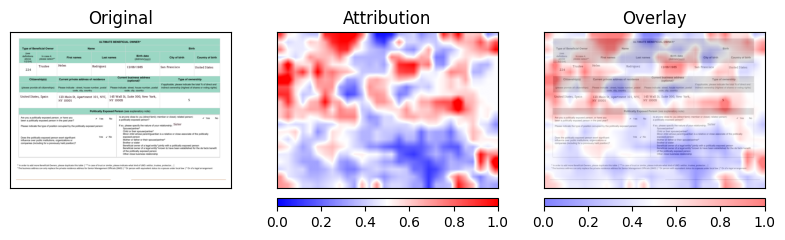

In [38]:
json_key = "Type of ownership"
average = True # Average maps from all the tokens

plot_heatmap(json_key,
             res,
             average=average,
             idx=0)